# Abstract

This study investigates the relationship between Spotify audio features and Billboard chart performance. The dataset combines Spotify track-level audio characteristics with Billboard Hot 100 chart information, allowing songs to be compared according to chart status, genre, decade, and normalized chart success. The analysis uses exploratory visualizations, standardized feature comparisons, correlation heatmaps, Welch’s t-tests, Mann-Whitney U tests, point-biserial correlations, and Spearman correlations. The results show that charted and non-charted songs differ significantly across all tested Spotify features. Charted songs are generally more popular, louder, more energetic, more danceable, less acoustic, and less instrumental. However, most correlation values are modest, showing that no single audio feature fully explains chart success. The findings also show that the importance of specific features changes across genres and decades. Overall, the study suggests that Spotify audio features are meaningfully related to Billboard chart presence and chart strength, but chart success is best understood as a combination of musical characteristics, genre context, historical period, or it could be external industry factors like musician's reputation, addvertisement most probably or sometimes purely creative magic.


# 1. Introduction

The emergence of music streaming platforms has transformed the modern music industry by providing large-scale access to listener behavior and detailed musical metadata. Spotify, one of the world’s largest streaming services, offers quantitative descriptions of songs through audio features such as danceability, energy, valence, tempo, loudness, acousticness, etc. These variables provide an opportunity to analyze music using statistical and data science methods (Morris & Powers, 2015).

At the same time, commercial music charts such as the Billboard Hot 100 remain among the most widely recognized indicators of musical success and public popularity. Billboard rankings reflect commercial performance through streaming, radio airplay, and sales data, making them a useful external measure of popularity independent and not to be mistaken with Spotify’s internal popularity coefficient (Billboard, 2025).

The combination of Spotify audio features and Billboard chart data allows for the investigation of relationships between musical characteristics and commercial success. Understanding these relationships is valuable not only for academic purposes, but also for artists, producers, streaming platforms, and the music industry as a whole.

This project investigates whether specific Spotify audio features are associated with the probability by which a track could obtain a place in the charts or if already in the charts, to obtain stronger Billboard chart performance. The study follows a standard data workflow consisting of data acquisition, cleaning and consolidation as two types of independent datasets are combined: Two Spotify audio feature datasets and Billboard chart ranking data. Afterwards, the project exposes statistical relationships between musical properties and chart success through the dimensions of time and music genre by conducting exploratory data analysis, visualization, and hypothesis testing. Results and discussion follow next, as well as conclusion at the end.


# 2. Related Work

The analysis of music using quantitative methods has become increasingly common due to the availability of large streaming datasets and advances in data science. Previous research has examined recommendation systems, genre classification, popularity prediction, and emotional analysis of music.

Spotify audio features have frequently been used in machine learning and statistical studies because they provide numerical representations of perceptual musical properties. Features such as danceability, energy, and valence are commonly analyzed to identify genre differences and listener preferences (Schedl, Gómez, & Urbano, 2014).

Several studies suggest that commercially successful songs share common characteristics. Popular tracks are often associated with higher loudness, stronger rhythmic structure, and higher danceability values. Research on musical hit prediction has shown that audio features can be significant predictors of commercial success (Pachet & Roy, 2008; Herremans, Martens, & Sörensen, 2014).

Other research has investigated temporal trends in music, including the so-called “loudness war” and changes in musical complexity over time. Serrà et al. (2012) observed increasing loudness and homogenization in modern popular music, suggesting that commercial pressures may influence production styles.

Billboard rankings have also been used as indicators of commercial success in studies involving predictive analytics and trend forecasting. Dhanaraj and Logan (2005) explored the prediction of hit songs using audio and metadata features, while more recent studies have investigated streaming-era popularity prediction using large-scale music datasets.

This project differs from many existing studies by emphasizing interpretability, statistical hypothesis testing, exploratory visualization, and reproducible data-processing workflows rather than solely predictive modeling.


# 3. Data

## 3.1 Data Extraction

The datasets used in this project were obtained from publicly available online repositoriess in CSV format and loading them into pandas DataFrames using Python. 

### 3.1.1. Spotify datasets

Spotify audio-feature data was collected from a publicly available Kaggle dataset (see Appendix A for links) containing approximately 100,000 songs across multiple genres and release periods. Another Spotify-based Kaggle dataset, containing over 160,000 songs was also loaded. The only difference with the previous dataset is that this dataset had a column year, but didn't have any column about genre (as the previous one had). The datasets include numerical audio descriptors generated by Spotify’s internal music-analysis algorithms, including variables such as song title, artist, genre, danceability, energy, valence, loudness, tempo, acousticness, speechiness, instrumentalness, liveness, and Spotify popularity score.(Spotify for Developers, 2025). Here is more info about each of them:

#### A) Popularity
A Spotify-based score that estimates how popular a track is on the platform. Higher values usually indicate more recent or more frequently streamed tracks.

#### B) Danceability
Measures how suitable a track is for dancing. It is based on rhythm, tempo stability, beat strength, and overall regularity. Higher values mean the song is more danceable.
#### C)Energy
Measures how intense and active a track feels. High-energy songs usually sound fast, loud, powerful, or aggressive. Low-energy songs feel calmer or softer.

#### D)Loudness
Measures the overall volume of a track in decibels. Values are usually negative. A value closer to zero means the track is louder.

#### E)Speechiness
Measures the presence of spoken words in a track. Higher values suggest more speech-like content, such as rap, spoken word, or podcasts.

#### F)Acousticness
Estimates how acoustic a track sounds. Higher values mean the song is more likely to contain acoustic instruments or have a less electronic/produced sound.

#### G)Instrumentalness
Estimates whether a track contains vocals. Higher values mean the track is more likely to be instrumental. Lower values usually indicate vocal-based songs.

#### H)Liveness
Estimates whether a track was performed live. Higher values suggest the presence of audience noise or live-performance characteristics.

#### I)Valence
Measures the musical positivity of a track. Higher valence means the song sounds happier, brighter, or more cheerful. Lower valence means it may sound sadder, darker, or more serious.

#### J)Tempo
Measures the speed of the track in beats per minute, also known as BPM. Higher tempo means a faster song.

### 3.1.2. Billboard chart dataset
Billboard chart data was obtained from a historical Billboard Hot 100 dataset containing time serial weekly chart rankings, peak chart positions, and chart duration information from the years between 1958 and 2021. The years from the 50s are considered in this study to be united with the years from the 60s, and the years from 2020s to be united with the years from 2010s because they represent very small fraction and are incomplete. The dataset provides an external measure of commercial song success independent from Spotify’s platform-specific popularity metric.


## 3.2 Data cleaning and consolidation

Since the datasets originated from independent sources, preprocessing and consolidation were required before analysis. Song titles and artist names were normalized by converting text to lowercase, removing any special symbols and spaces. Keywords such as  “remastered” , “live", etc. in the name of the tracks were eliminated in order to allow better migration. For more information, regarding the process of cleaning the data (see Appendix A).

In short, after normalization, the two Spotify datasets were concatinated. Duplicate entries and incomplete observations were removed in order to improve consistency and reduce matching errors. Then all the weekly data per a track from the Billboard table was transformed and aggrevated into a single row, containing aggrevated data such as maximum week count in the chart, minimum peak rank, minimum year of rank entry, sum of the CSS index (more in detail about the index in 3.3). Then the summarized Billboard data was innerly merged on song titles and artist names with the combined/ concatinated Spotidy data. The resulting consolidated dataset contained around 11K records (so called Charted data) with both Spotify audio characteristics and Billboard chart-performance indicators, enabling comparative statistical analysis between musical properties and commercial success. The combined Spotify data was filtered to have only the years from 1958 till 2021 in order to reflect the Billboard data and was concatinated with the consolidated Billboard/Spotify data (resulting in over 100K records) so that a whole dataset of charted and non-charted tracks to be obtained. Finally, an AI tool (chatgpt) was used in order to classify and populate the records of tracks missing genre data. A reference table with artist, track name and genre is finally merged with the final consolidated charted and non-charted data.



Several Spotify audio features displayed skewed distributions, particularly instrumentalness, speechiness, liveness, and acousticness (see 5.2 from Exploratory Analysis). This is expected because most commercially released tracks are vocal-based studio recordings, resulting in many low values for instrumentalness and liveness. Because some variables were not normally distributed, exploratory visualizations were supported with correlation-based and non-parametric statistical approaches where appropriate. The skewed distributions of these variables was not "normalized" as this research doesn't intend to build predictive analysis, in which such normalization would typically be applied, but rather only observes relations.

## 3.3 Adding Chart Success Score

In order to obtain a more comprehensive measure of commercial success, a derived metric called the Chart Success Score (CSS) was introduced. Billboard chart datasets contain several indicators of success, including peak chart position and total weeks spent on the chart. However, each variable individually captures only a single dimension of popularity.

For example, some songs may achieve a very high chart position for a short period of time, while others may remain on the charts for many weeks without reaching the top positions. To address this limitation, the Chart Success Score combines both ranking performance and chart longevity into a single numerical measure for each weekly record per given track.


For each weekly Billboard observation:
The score is defined as:


$$
CSS_{weekly} = \frac{101 - rank}{100}
$$


Where:

rank 1  would equal 1.00

rank 100 would equal 0.01




After computing the Chart Success Score (CSS), the values were normalized using z-score normalization. This procedure provides several advantages. First, it allows variables measured on different numerical scales to be compared more directly. Second, normalization reduces the influence of extreme values and improves interpretability during correlation and regression analysis. Finally, standardized variables simplify visualization and statistical comparison between groups. Positive normalized values indicate songs performing above the dataset average in terms of commercial success, while negative values indicate below-average performance. The normalized Chart Success Score was subsequently used as the primary dependent variable during correlation analysis, hypothesis testing, and exploratory visualization.

The normalized Chart Success Score is defined as:

$$
CSS_{normalized} =
\frac{CSS - \mu_{CSS}}
{\sigma_{CSS}}
\times 100
$$


where:

CSS - the original Chart Success Score

μ - mean value of the Chart Success Score across all observations

σ - standard deviation of the Chart Success Score.

# 4. Limitations

Several limitations affect the analysis presented in this study.First, Spotify audio features are generated by proprietary algorithms whose exact implementation is not publicly available. As a result, some variables may contain hidden assumptions or biases that cannot be fully evaluated.
Second, Billboard rankings are influenced by multiple external factors beyond musical structure itself. Marketing campaigns, artist popularity, radio promotion, social media trends, and seasonal or eventful listening behavior may all influence chart success (Datta, Knox, & Bronnenberg, 2018).
Another limitation concerns dataset consolidation. Since the datasets are merged using song titles and artist names, mismatches may occur due to alternative spellings, featured artists, remastered editions, or regional naming conventions. Another limitation is simply by the fact that the analysis is observational rather than experimental. Consequently, even when statistically significant relationships are identified, correlation does not imply causation. A strong relationship between danceability and chart success, for example, does not necessarily mean that danceability directly causes popularity. Finally due to the lack of proper dataset concerning the genres classification, an AI-based classification was used in order to populate the track_genre column for the records based on the track_name, artist and year. Therefore, genre data could be not completely right at parts due to wrongly assignment of genre from the AI algorithm.


# 5. Exploratory Data Analysis


The goal of the exploratory analysis is to understand how Spotify audio features are distributed, how charted and non-charted songs differ, how musical characteristics change across decades, and how genre is related to both musical structure and Billboard performance.

## 5.1 Standardized audio-feature differences by chart status

This graph compares charted and non-charted tracks after standardizing the numerical Spotify features. Standardization makes features with different scales, such as `tempo`, `loudness`, and `danceability`, comparable in the same figure. Positive values indicate that a group is above the overall dataset average for that feature, while negative values indicate that it is below average. As seen in the graph, charted tracks generally show higher values for popularity, loudness, energy, danceability, and valence. Non-charted tracks show higher values for acousticness, instrumentalness, liveness, and speechiness. This suggests that charted songs tend to have a more commercial, vocal-based, energetic, and produced sound profile.


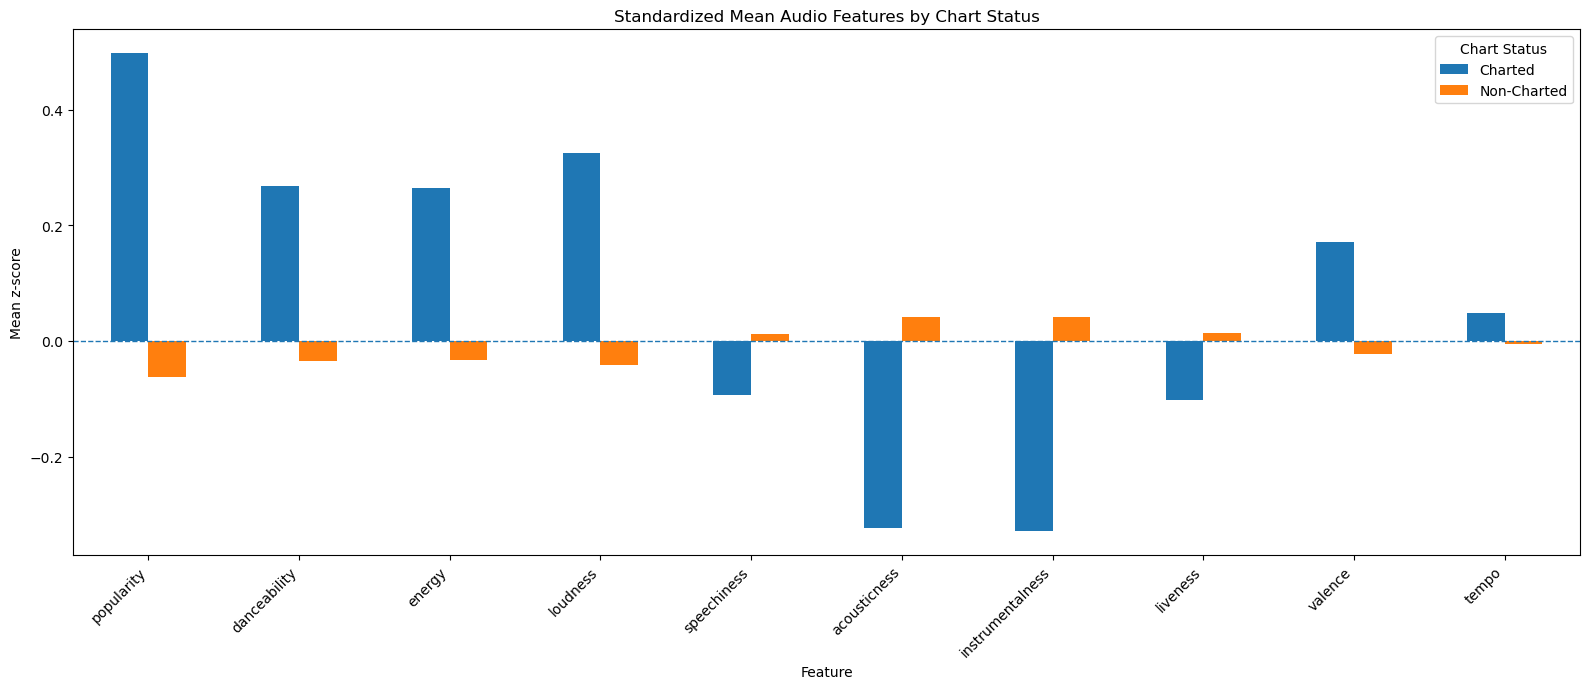

In [3]:

excluded_columns = [
    "year",
    "decade",
    "weeks_on_board",
    "peak_rank",
    "charted_binary",
    "CSS",
    "CSS_normalized"
]

numeric_columns = final_df.select_dtypes(include=["number"]).columns

feature_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

standardized_df = final_df.copy()

for col in feature_columns:
    standardized_df[col + "_z"] = (
        standardized_df[col] - standardized_df[col].mean()
    ) / standardized_df[col].std()

z_columns = [col + "_z" for col in feature_columns]

z_means_by_chart_status = (
    standardized_df
    .groupby("charted_label")[z_columns]
    .mean()
    .T
    .round(3)
)

z_means_by_chart_status.index = feature_columns

z_means_by_chart_status


z_means_by_chart_status.plot(
kind="bar",
figsize=(16, 7)
)

plt.title("Standardized Mean Audio Features by Chart Status")
plt.xlabel("Feature")
plt.ylabel("Mean z-score")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend(title="Chart Status")
plt.tight_layout()
plt.show()





## 5.2 Standardized audio-feature trends by decade


These two line graphs show how average Spotify audio features change across decades (see Appendix D for numerical representation). The values are standardized, so the y-axis represents the average z-score for each feature in each decade. This allows features measured on different scales to be compared in the same visualization. As what could be concluded on first glance from the graph, loudness, danceability and energy tend to increase in more recent decades, which may reflect changes in music production and mastering. Acousticness and instrumentalness are generally lower in later decades, suggesting a movement toward more produced and vocal-centered music. These trends show that the musical characteristics of the dataset are historically dependent.


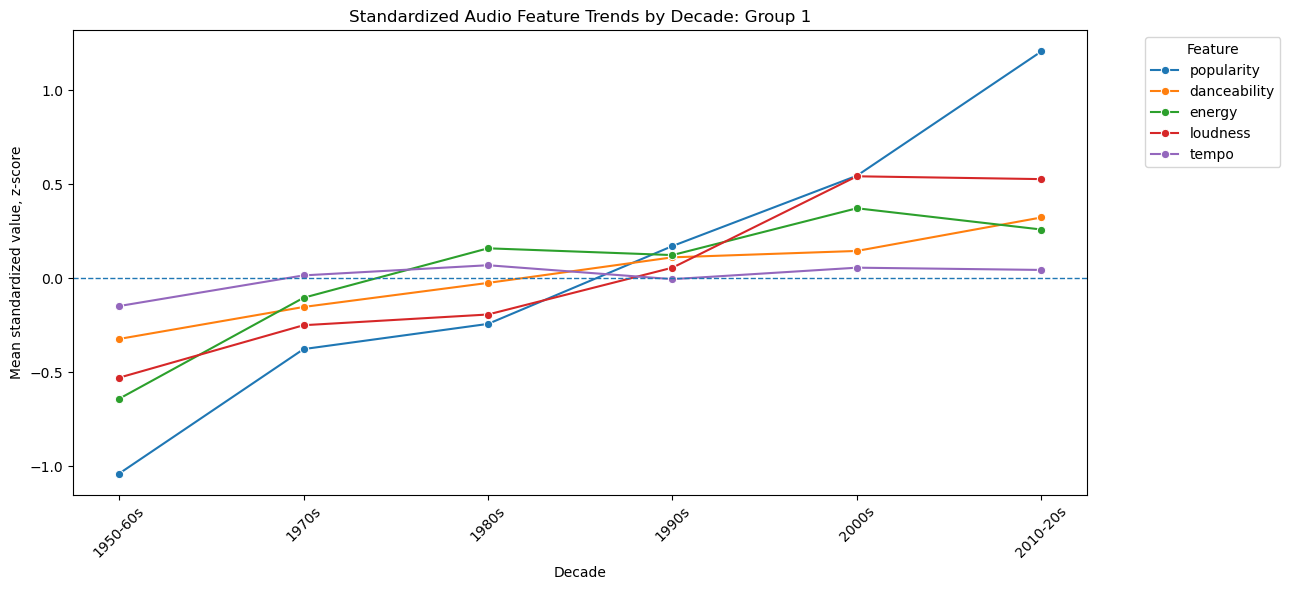

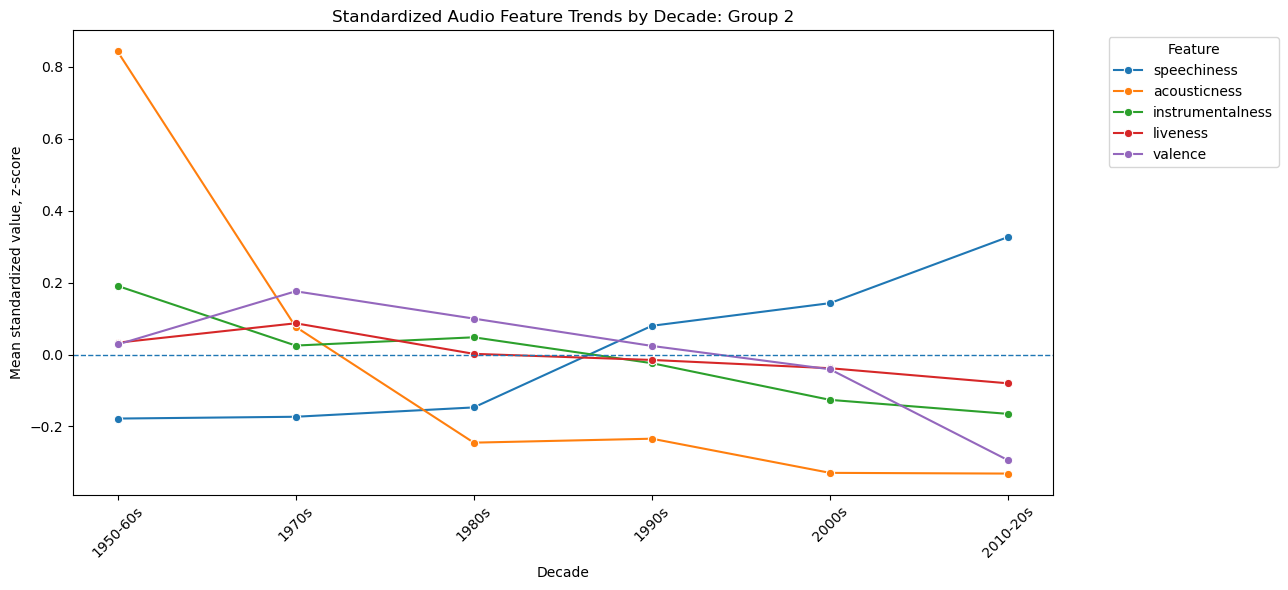

In [4]:
# Create standardized mean audio features by decade

excluded_columns = [
    "year",
    "decade",
    "weeks_on_board",
    "peak_rank",
    "charted_binary",
    "CSS",
    "CSS_normalized"
]

numeric_columns = final_df.select_dtypes(include=["number"]).columns

feature_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

standardized_df = final_df.copy()

for col in feature_columns:
    standardized_df[col + "_z"] = (
        standardized_df[col] - standardized_df[col].mean()
    ) / standardized_df[col].std()

z_columns = [col + "_z" for col in feature_columns]

decade_feature_means_z = (
    standardized_df
    .groupby("decade_label", observed=True)[z_columns]
    .mean()
    .sort_index()
    .round(3)
)

decade_feature_means_z.columns = feature_columns

decade_feature_means_z


feature_group_1 = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "tempo"
]

feature_group_2 = [
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]


group_1_trends = decade_feature_means_z[feature_group_1]

group_1_long = (
    group_1_trends
    .reset_index()
    .melt(
        id_vars="decade_label",
        var_name="feature",
        value_name="mean_z_score"
    )
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=group_1_long,
    x="decade_label",
    y="mean_z_score",
    hue="feature",
    marker="o"
)

plt.title("Standardized Audio Feature Trends by Decade: Group 1")
plt.xlabel("Decade")
plt.ylabel("Mean standardized value, z-score")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


group_2_trends = decade_feature_means_z[feature_group_2]

group_2_long = (
    group_2_trends
    .reset_index()
    .melt(
        id_vars="decade_label",
        var_name="feature",
        value_name="mean_z_score"
    )
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=group_2_long,
    x="decade_label",
    y="mean_z_score",
    hue="feature",
    marker="o"
)

plt.title("Standardized Audio Feature Trends by Decade: Group 2")
plt.xlabel("Decade")
plt.ylabel("Mean standardized value, z-score")
plt.xticks(rotation=45)
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5.3 Distribution of Spotify audio features


These histograms show the distribution of each Spotify audio feature in the full dataset. This step is important because it shows whether the variables are approximately balanced, concentrated around particular values, or strongly skewed. As seen from graphs, features such as instrumentalness, speechiness, and liveness have many values close to zero, which is expected because most songs are vocal-based studio recordings rather than instrumental, spoken, or live tracks. Other variables such as danceability, energy, valence, and tempo are more evenly distributed. These distributions show that non-parametric methods such as Spearman correlation are useful for some parts of the analysis.


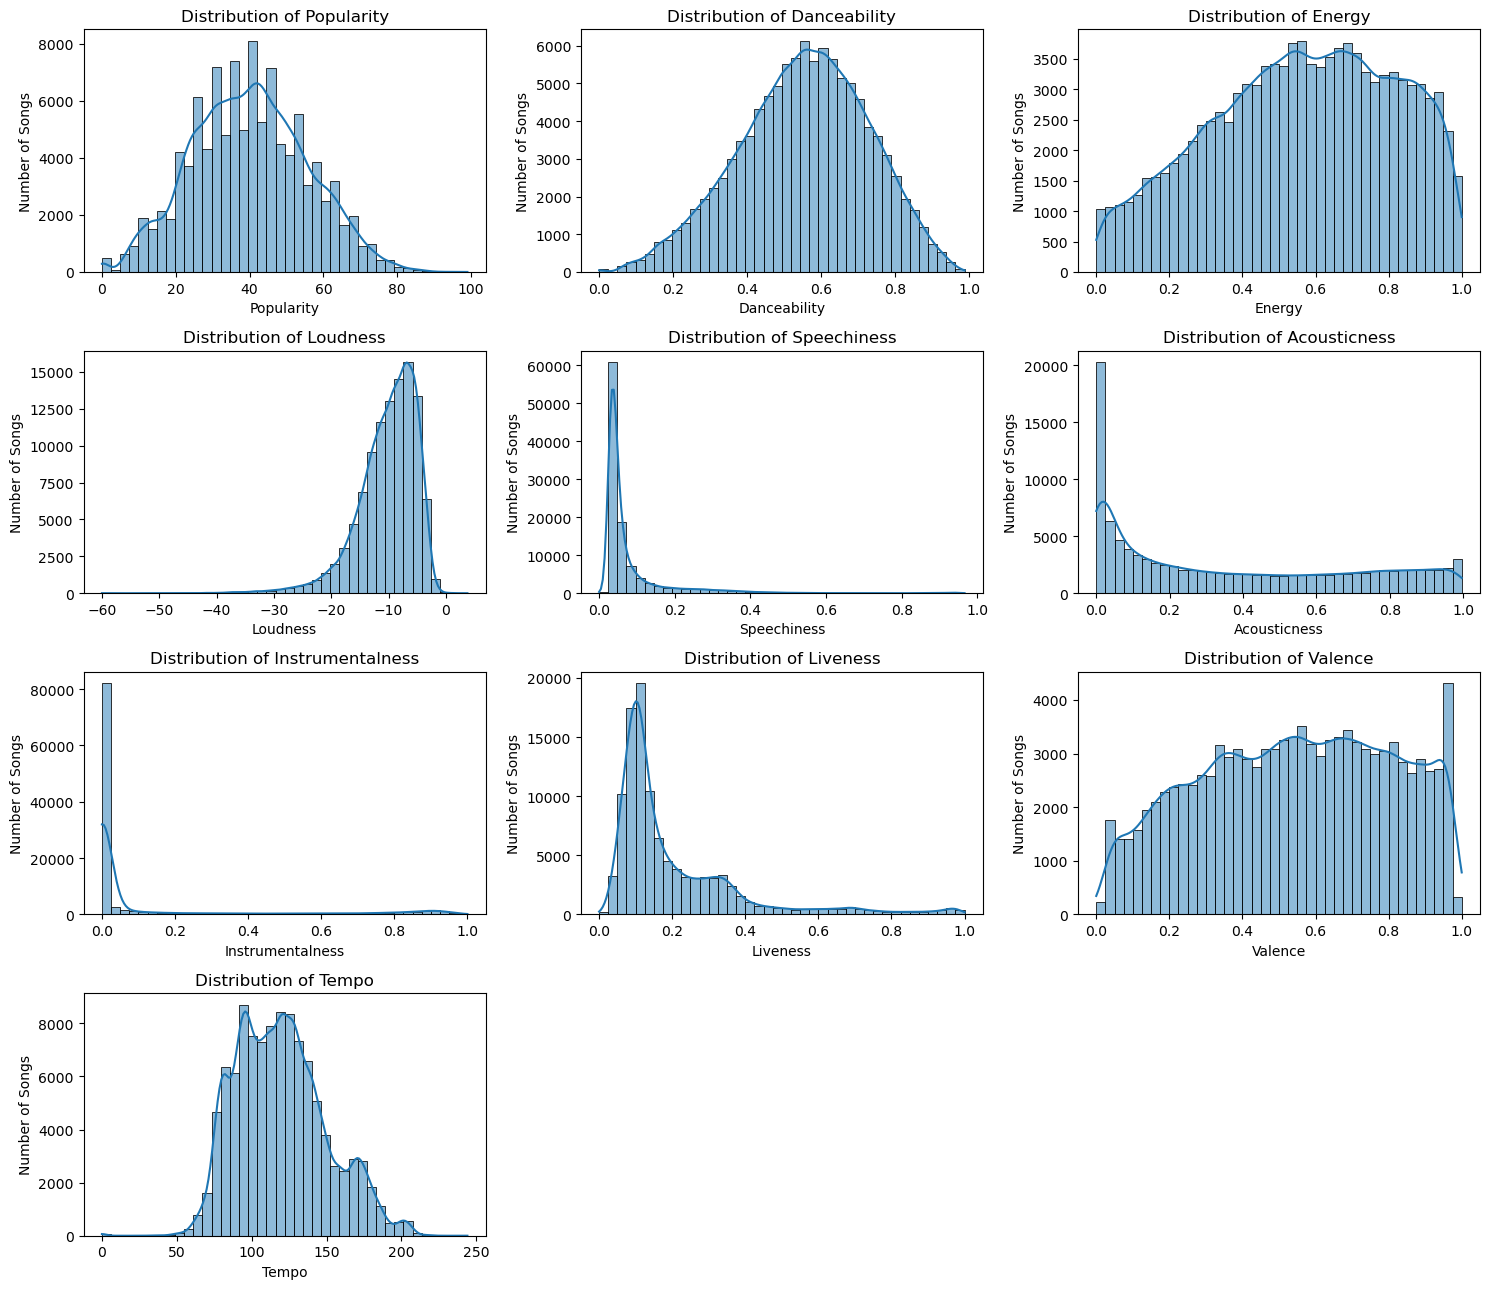

In [5]:
audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15, 13)
)

axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.histplot(
        data=final_df,
        x=feature,
        bins=40,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature.capitalize()}")
    axes[i].set_xlabel(feature.capitalize())
    axes[i].set_ylabel("Number of Songs")


for j in range(len(audio_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5.4 Audio features as indicators of charted status by decade


This heatmap examines whether each Spotify audio feature is associated with a track being **charted** rather than **non-charted** within each decade.

The analysis uses `charted_binary`, where `1` means charted and `0` means non-charted. Because the outcome variable is binary, the graph uses point-biserial correlation. Positive values mean that higher values of that feature are more common among charted tracks in that decade. Negative values mean that higher values of that feature are more common among non-charted tracks.

The stars indicate statistical significance: `* p < 0.05`, `** p < 0.01`, and `*** p < 0.001`. In simple terms, this graph helps answer whether particular musical characteristics made a song more likely to appear on Billboard in specific decades.

On first glance at the heatmap, it could be noticed that popularity is consistently a positive indicator across decades, while other features vary more strongly over time. Loudness, danceability, acousticness, and instrumentalness show decade-specific patterns, meaning that the features linked to chart presence are not the same in every period. For example, loudness appears as a positive indicator in several decades, while acousticness and instrumentalness often show negative relationships. This suggests that Billboard chart presence depends not only on the song’s audio characteristics, but also on the historical period in which the song was released or charted. The graph therefore supports the idea that commercial music trends change over time.


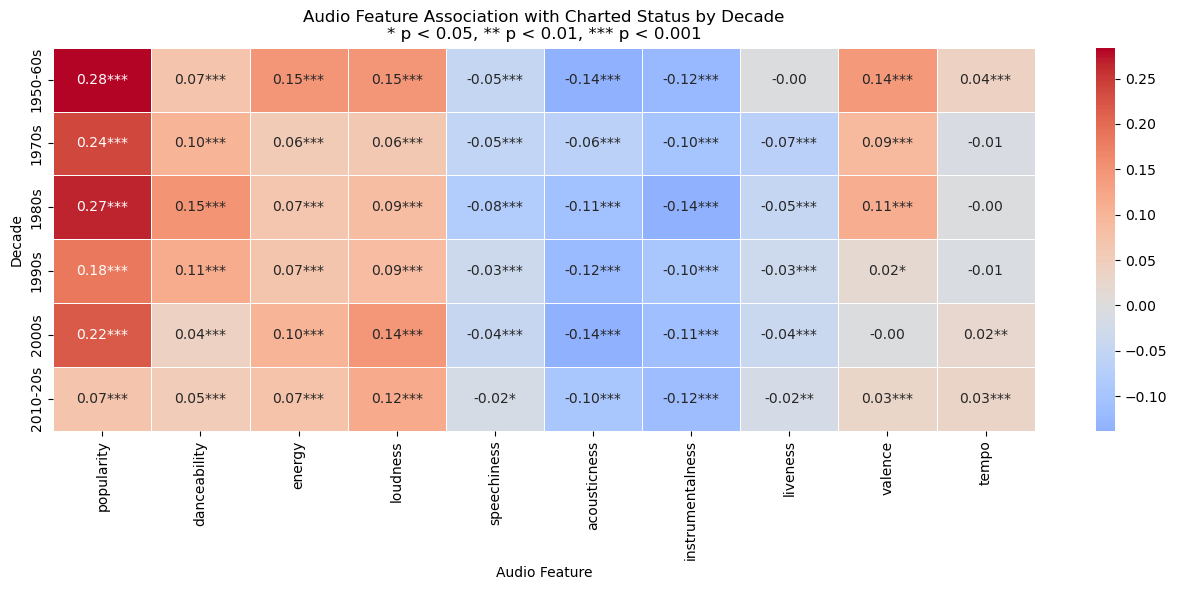

In [16]:
from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_tracks_per_decade = 1000


decade_order = [
    "1950-60s",
    "1970s",
    "1980s",
    "1990s",
    "2000s",
    "2010-20s"
]

final_df["decade_label"] = final_df["decade_label"].astype(str)

final_df["decade_label"] = pd.Categorical(
    final_df["decade_label"],
    categories=decade_order,
    ordered=True
)

valid_decades = (
    final_df["decade_label"]
    .value_counts()
    .loc[lambda x: x >= min_tracks_per_decade]
    .index
)

decade_df = final_df[
    final_df["decade_label"].isin(valid_decades)
].copy()

decade_feature_chart_corr = pd.DataFrame(
    index=decade_order,
    columns=selected_features,
    dtype=float
)

decade_feature_chart_pvalues = pd.DataFrame(
    index=decade_order,
    columns=selected_features,
    dtype=float
)

for decade in decade_order:
    decade_data = decade_df[
        decade_df["decade_label"] == decade
    ].copy()

    # Skip decades with too few records
    if len(decade_data) < min_tracks_per_decade:
        continue

    for feature in selected_features:
        temp_df = decade_data[[feature, "charted_binary"]].dropna()

        # Need both charted and non-charted tracks present
        if (
            len(temp_df) >= min_tracks_per_decade and
            temp_df["charted_binary"].nunique() == 2
        ):
            corr, p_value = pointbiserialr(
                temp_df["charted_binary"],
                temp_df[feature]
            )

            decade_feature_chart_corr.loc[decade, feature] = corr
            decade_feature_chart_pvalues.loc[decade, feature] = p_value

decade_feature_chart_corr = decade_feature_chart_corr.dropna(how="all").round(3)
decade_feature_chart_pvalues = decade_feature_chart_pvalues.dropna(how="all").round(4)

annot_matrix = decade_feature_chart_corr.copy().astype(str)

for decade in decade_feature_chart_corr.index:
    for feature in decade_feature_chart_corr.columns:
        corr_value = decade_feature_chart_corr.loc[decade, feature]
        p_value = decade_feature_chart_pvalues.loc[decade, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[decade, feature] = ""
        elif p_value < 0.001:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}***"
        elif p_value < 0.01:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}**"
        elif p_value < 0.05:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}*"
        else:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}"


plt.figure(figsize=(13, 6))

sns.heatmap(
    decade_feature_chart_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Audio Feature Association with Charted Status by Decade\n"
    "* p < 0.05, ** p < 0.01, *** p < 0.001"
)
plt.xlabel("Audio Feature")
plt.ylabel("Decade")

plt.tight_layout()
plt.show()









## 5.5 Audio features and normalized Billboard success by decade


This heatmap uses only charted tracks and investigates whether the relationship between Spotify audio features and Billboard success changed over time. The outcome variable is `CSS_normalized`, where higher values indicate stronger normalized Billboard performance.

For each decade, Spearman correlation is calculated between each audio feature and `CSS_normalized`. Positive values indicate that higher feature values are associated with stronger chart performance in that decade. Negative values indicate the opposite. The stars indicate statistical significance. It could be clearly seen that popularity is the most consistent positive feature across all decades, indicating that Spotify popularity and Billboard success are related. Other features show more specific historical patterns, such as danceability being more relevant in some decades and speechiness or instrumentalness being negatively associated in others. This means that the characteristics linked to stronger chart performance are not stable across time. A feature that is useful for explaining success in one decade may be weak or irrelevant in another. This graph helps separate chart entry from chart strength, because it looks only at songs that already reached Billboard.


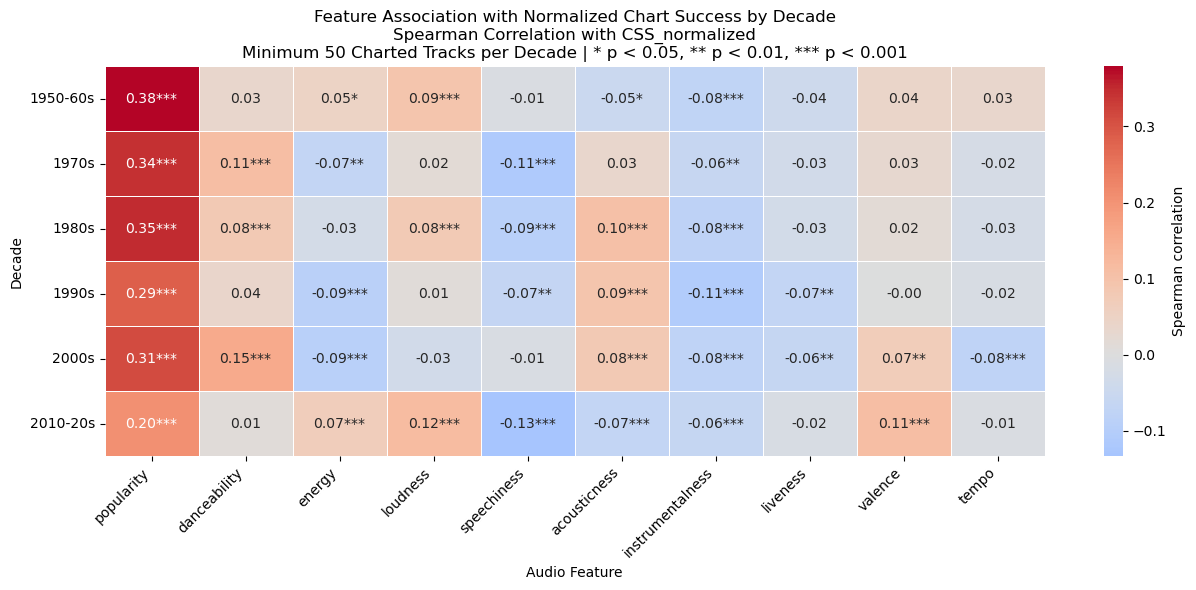

In [17]:


from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()




selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]




min_tracks = 50

valid_decades = (
    charted_df["decade_label"]
    .value_counts()
    .loc[lambda x: x >= min_tracks]
    .index
)

charted_decade_df = charted_df[
    charted_df["decade_label"].isin(valid_decades)
].copy()




decade_feature_css_corr = pd.DataFrame(
    index=sorted(valid_decades),
    columns=selected_features,
    dtype=float
)

decade_feature_css_pvalues = pd.DataFrame(
    index=sorted(valid_decades),
    columns=selected_features,
    dtype=float
)




for decade in sorted(valid_decades):
    
    decade_data = charted_decade_df[
        charted_decade_df["decade_label"] == decade
    ]

    for feature in selected_features:
        
        temp_df = decade_data[
            [feature, "CSS_normalized"]
        ].dropna()

        if len(temp_df) >= min_tracks:
            
            # Spearman requires variation in both variables
            if temp_df[feature].nunique() < 2:
                continue

            if temp_df["CSS_normalized"].nunique() < 2:
                continue

            corr, p_value = spearmanr(
                temp_df[feature],
                temp_df["CSS_normalized"]
            )

            decade_feature_css_corr.loc[decade, feature] = corr
            decade_feature_css_pvalues.loc[decade, feature] = p_value




decade_feature_css_corr = decade_feature_css_corr.round(3)
decade_feature_css_pvalues = decade_feature_css_pvalues.round(5)




annot_matrix = decade_feature_css_corr.copy().astype(str)

for decade in decade_feature_css_corr.index:
    
    for feature in decade_feature_css_corr.columns:
        
        corr_value = decade_feature_css_corr.loc[decade, feature]
        p_value = decade_feature_css_pvalues.loc[decade, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[decade, feature] = ""

        elif p_value < 0.001:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}***"

        elif p_value < 0.01:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}**"

        elif p_value < 0.05:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}*"

        else:
            annot_matrix.loc[decade, feature] = f"{corr_value:.2f}"




plt.figure(figsize=(13, 6))

sns.heatmap(
    decade_feature_css_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Spearman correlation"}
)

plt.title(
    "Feature Association with Normalized Chart Success by Decade\n"
    "Spearman Correlation with CSS_normalized\n"
    f"Minimum {min_tracks} Charted Tracks per Decade | "
    "* p < 0.05, ** p < 0.01, *** p < 0.001"
)

plt.xlabel("Audio Feature")
plt.ylabel("Decade")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 5.6 Audio features as indicators of charted status by genre


This heatmap examines whether each Spotify audio feature is associated with a track being charted rather than non-charted within each music genre. Because the dependent variable is binary, point-biserial correlation is used.

Positive values mean that higher feature values are more common among charted tracks within that genre. Negative values mean that higher feature values are more common among non-charted tracks. This graph is useful because the meaning of a feature may differ by genre; for example, high `energy` may be normal in rock but more distinctive in acoustic music. As seen, popularity is a common positive indicator, but features such as loudness, energy, danceability, acousticness, and instrumentalness behave differently depending on the genre. This means that a feature that helps distinguish charted songs in one genre may not have the same role in another. For example, danceability may be more meaningful in dance or pop-related genres, while instrumentalness may be more important in genres where vocal presence strongly affects commercial accessibility. The graph shows that it is not enough to analyze charted status only at the full-dataset level. Genre-specific analysis gives a more detailed view of how musical characteristics relate to Billboard presence.


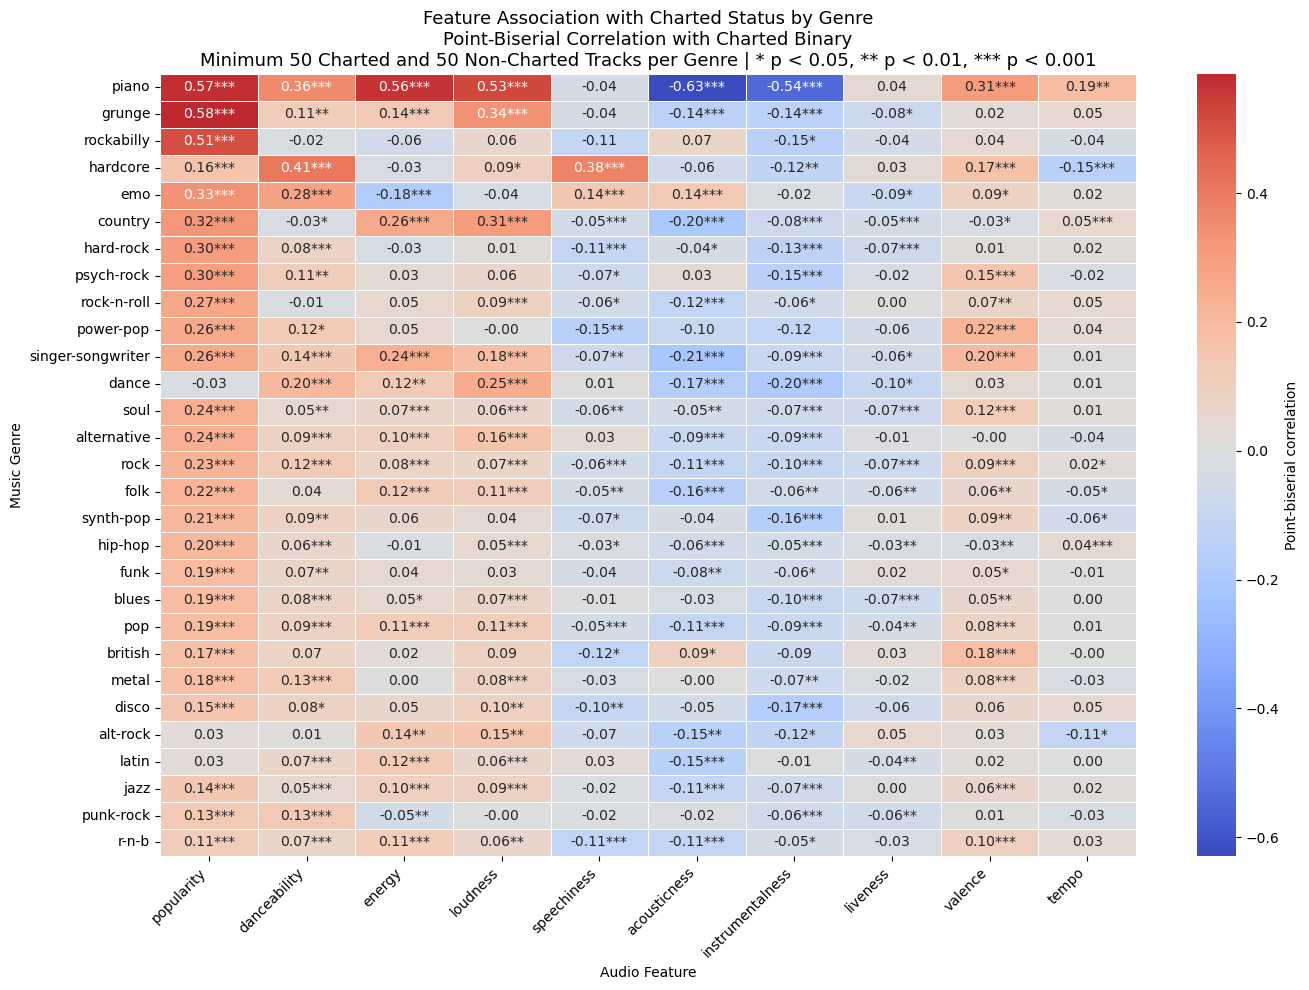

In [18]:

from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_charted = 50
min_non_charted = 50



analysis_df = final_df[
    ["track_genre", "charted_binary"] + audio_features
].dropna(
    subset=["track_genre", "charted_binary"]
).copy()


corr_results = {}
pvalue_results = {}

for genre, group in analysis_df.groupby("track_genre"):

    class_counts = group["charted_binary"].value_counts()

    charted_count = class_counts.get(1, 0)
    non_charted_count = class_counts.get(0, 0)

    # Require at least 50 charted and 50 non-charted tracks
    if charted_count < min_charted:
        continue

    if non_charted_count < min_non_charted:
        continue

    feature_corrs = {}
    feature_pvalues = {}

    for feature in audio_features:

        temp = group[[feature, "charted_binary"]].dropna()

        class_counts_temp = temp["charted_binary"].value_counts()

        charted_count_temp = class_counts_temp.get(1, 0)
        non_charted_count_temp = class_counts_temp.get(0, 0)

       
        if charted_count_temp < min_charted:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan
            continue

        if non_charted_count_temp < min_non_charted:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan
            continue

        # Feature must have variation
        if temp[feature].nunique() < 2:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan
            continue

        corr, p_value = pointbiserialr(
            temp["charted_binary"],
            temp[feature]
        )

        feature_corrs[feature] = corr
        feature_pvalues[feature] = p_value

    corr_results[genre] = feature_corrs
    pvalue_results[genre] = feature_pvalues


genre_feature_chart_corr = (
    pd.DataFrame(corr_results)
    .T
    .round(3)
)

genre_feature_chart_pvalues = (
    pd.DataFrame(pvalue_results)
    .T
)



genre_feature_chart_corr = genre_feature_chart_corr.dropna(how="all")

genre_feature_chart_pvalues = genre_feature_chart_pvalues.reindex(
    index=genre_feature_chart_corr.index,
    columns=genre_feature_chart_corr.columns
)



genre_feature_chart_corr = genre_feature_chart_corr.loc[
    genre_feature_chart_corr
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .index
]

genre_feature_chart_pvalues = genre_feature_chart_pvalues.reindex(
    index=genre_feature_chart_corr.index,
    columns=genre_feature_chart_corr.columns
)



annot_matrix = genre_feature_chart_corr.copy().astype(str)

for genre in genre_feature_chart_corr.index:
    for feature in genre_feature_chart_corr.columns:

        corr_value = genre_feature_chart_corr.loc[genre, feature]
        p_value = genre_feature_chart_pvalues.loc[genre, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[genre, feature] = ""

        elif p_value < 0.001:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}***"

        elif p_value < 0.01:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}**"

        elif p_value < 0.05:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}*"

        else:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}"



plt.figure(figsize=(14, 10))

sns.heatmap(
    genre_feature_chart_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Point-biserial correlation"}
)

plt.title(
    "Feature Association with Charted Status by Genre\n"
    "Point-Biserial Correlation with Charted Binary\n"
    f"Minimum {min_charted} Charted and {min_non_charted} Non-Charted Tracks per Genre | "
    "* p < 0.05, ** p < 0.01, *** p < 0.001",
    fontsize=13
)

plt.xlabel("Audio Feature")
plt.ylabel("Music Genre")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 5.7 Audio features and normalized Billboard success by genre


This heatmap focuses only on tracks that appeared on the Billboard chart. Instead of comparing charted and non-charted tracks, it investigates whether specific audio features are associated with stronger chart performance within each genre.

The outcome variable is `CSS_normalized`. Spearman correlation is used because chart-success values are likely skewed. Positive values suggest that higher feature values are associated with higher normalized chart success within a genre. Negative values suggest that higher feature values are associated with lower normalized chart success. And again, popularity is one of the most frequent positive indicators, but several genres show their own specific patterns. For example, instrumentalness may be negatively related to success in some genres, while danceability, valence, or energy may matter more in others. This suggests that the “successful sound” is not universal, but depends strongly on genre conventions. The graph is useful because it shows that after a song has already charted, the features related to higher chart success can still differ by genre. Therefore, Billboard success should be interpreted as both genre-specific and performance-specific, not only as a general charted/non-charted outcome.


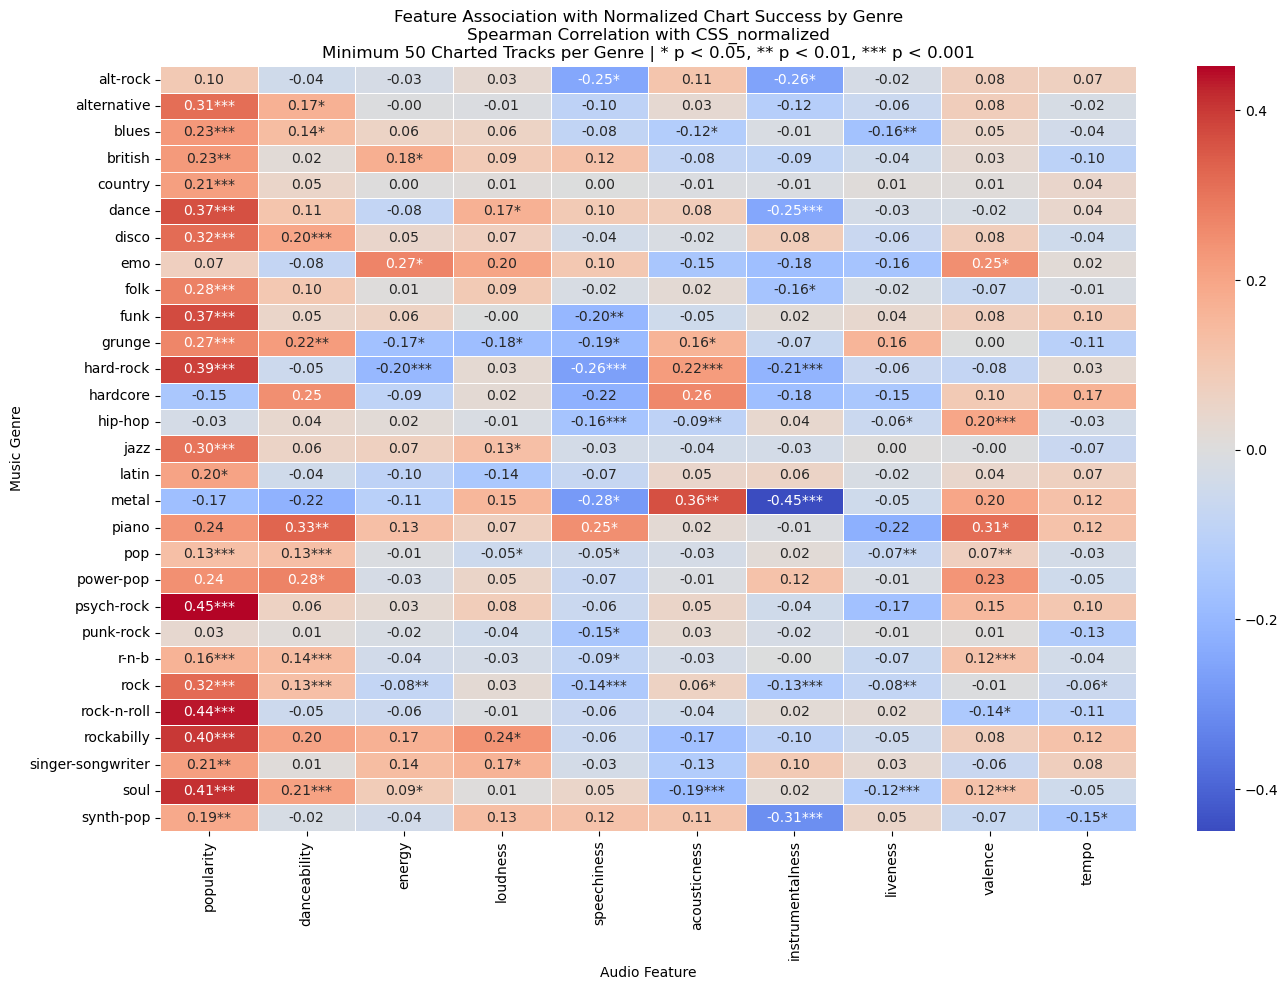

In [19]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_tracks = 50

charted_df = final_df.loc[
    final_df["charted_label"].eq("Charted"),
    ["track_genre", "CSS_normalized"] + audio_features
].dropna(subset=["track_genre", "CSS_normalized"])

genre_counts = charted_df["track_genre"].value_counts()
valid_genres = genre_counts[genre_counts >= min_tracks].index

charted_df = charted_df[
    charted_df["track_genre"].isin(valid_genres)
]

corr_results = {}
pvalue_results = {}

for genre, group in charted_df.groupby("track_genre"):
    feature_corrs = {}
    feature_pvalues = {}

    for feature in audio_features:
        temp = group[[feature, "CSS_normalized"]].dropna()

        if (
            len(temp) >= min_tracks
            and temp[feature].nunique() > 1
            and temp["CSS_normalized"].nunique() > 1
        ):
            corr, p_value = spearmanr(
                temp[feature],
                temp["CSS_normalized"]
            )

            feature_corrs[feature] = corr
            feature_pvalues[feature] = p_value

        else:
            feature_corrs[feature] = np.nan
            feature_pvalues[feature] = np.nan

    corr_results[genre] = feature_corrs
    pvalue_results[genre] = feature_pvalues


genre_feature_css_corr = (
    pd.DataFrame(corr_results)
    .T
    .round(3)
)

genre_feature_css_pvalues = (
    pd.DataFrame(pvalue_results)
    .T
)


# Create annotation matrix with stars
annot_matrix = genre_feature_css_corr.copy().astype(str)

for genre in genre_feature_css_corr.index:
    for feature in genre_feature_css_corr.columns:

        corr_value = genre_feature_css_corr.loc[genre, feature]
        p_value = genre_feature_css_pvalues.loc[genre, feature]

        if pd.isna(corr_value):
            annot_matrix.loc[genre, feature] = ""

        elif p_value < 0.001:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}***"

        elif p_value < 0.01:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}**"

        elif p_value < 0.05:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}*"

        else:
            annot_matrix.loc[genre, feature] = f"{corr_value:.2f}"


# Show only the heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    genre_feature_css_corr,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Feature Association with Normalized Chart Success by Genre\n"
    "Spearman Correlation with CSS_normalized\n"
    f"Minimum {min_tracks} Charted Tracks per Genre | "
    "* p < 0.05, ** p < 0.01, *** p < 0.001"
)

plt.xlabel("Audio Feature")
plt.ylabel("Music Genre")

plt.tight_layout()
plt.show()

## 5.8 Other graphs

Additional exploratory visualizations are uploaded from Appendix C until Appendix I,  that support the main analysis. These graphs are not used as the central evidence for the hypotheses, but they help explain the structure of the dataset and provide more detailed views of the relationships between variables.


Appendix C: Correlation analysis among the audio features shows the correlations between the numerical Spotify audio variables. This graph is used to understand how the features relate to each other before connecting them to Billboard performance.

Appendix D: Numerical representation of feature trends across decades provides the table behind the decade trend graphs. It shows the standardized mean value of each audio feature for each decade, making it easier to compare the numerical values behind the visual trend lines.

Appendix E: Top 3 best-performing CSS genres for each decade, minimum 50 charted tracks shows the highest-performing genres in each decade based on mean CSS_normalized. Its purpose is to summarize which genres achieved the strongest normalized Billboard success within each historical period.

Appendix F: Standardized genre feature profiles shows the average standardized audio-feature values for each genre. This graph explains which genres are generally more associated with features such as danceability, energy, acousticness, instrumentalness, or speechiness.

Appendix G: Genre success by decade based on mean CSS_normalized compares genres across decades using mean normalized Billboard success. This graph is used to show how genre-level chart performance changes over time.

Appendix H: Feature-specific chart-status heatmaps by genre and decade, minimum 50 charted and 50 non-charted tracks investigates each audio feature separately as an indicator of charted status. These graphs show where a feature is more strongly associated with being charted rather than non-charted within specific genre-decade combinations.

Appendix I: Feature-specific CSS_normalized heatmaps by genre and decade, minimum 50 charted tracks focuses only on charted songs and examines how each audio feature relates to stronger normalized Billboard success. These graphs help identify more specific genre-decade patterns that could be explored in future research.

# 6. Hypotheses and Methodology


The exploratory analysis shows that many different hypotheses could be developed from the visual patterns in the data. The graphs suggest possible differences between charted and non-charted songs, changes across decades, and genre-specific relationships between Spotify audio features and Billboard performance. Because the dataset allows many specific comparisons, this section focuses mainly on broader and more general phenomena. More detailed questions, such as whether one particular feature matters only in one specific genre and decade, could be investigated in future research with more targeted statistical testing.

## 6.1 Differences in audio-feature profiles between charted and non-charted songs

Graph 5.1 suggests that charted and non-charted songs may differ in their general audio-feature profiles. Some features appear higher on average among charted songs, while others appear lower. This motivates the hypothesis that Billboard-charted tracks are not randomly distributed across Spotify audio characteristics, but may have a distinct musical profile.

**H0:** There is no statistically significant difference in Spotify audio-feature values between charted and non-charted tracks.

**H1:** There is a statistically significant difference in at least one Spotify audio feature between charted and non-charted tracks.

The main grouping variable is chart status, represented by `charted_label` and `charted_binary`. The dependent variables are the Spotify audio features, including `popularity`, `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, and `tempo`. The methodology uses Welch’s two-sample t-test to compare the average value of each feature between charted and non-charted tracks. Since several variables have skewed distributions, the Mann-Whitney U test can also be used as a non-parametric robustness check.


## 6.2 Danceability as an indicator of charted status

Graph 5.1 may show that charted songs have a higher standardized mean value for `danceability`. This suggests that more danceable songs could be more likely to appear on the Billboard chart.

**H0:** Danceability is not significantly associated with whether a track is charted.

**H1:** Higher `danceability` is significantly associated with a greater likelihood that a track is charted.

The independent variable is `danceability`, and the dependent variable is `charted_binary`, where 1 means charted and 0 means non-charted. Because the outcome variable is binary and the predictor is numerical, the methodology uses point-biserial correlation. A positive and statistically significant correlation would suggest that higher `danceability` is associated with charted status.


## 6.3 Changes in chart-status indicators across decades

Graph 5.4 examines whether different audio features are associated with charted status across decades. If a feature has a positive relationship with charted status in one decade but a weaker or negative relationship in another, this suggests that the characteristics linked to chart entry changed over time.

**H0:** The relationship between Spotify audio features and charted status is the same across decades.

**H1:** The relationship between Spotify audio features and charted status differs across decades.

The dependent variable is `charted_binary`, while the independent variables are the Spotify audio features. The decade grouping variable is `decade_label`. The methodology calculates point-biserial correlations between each feature and charted status separately for each decade. This allows the analysis to identify whether features such as `danceability`, `energy`, `loudness`, or `instrumentalness` behave differently across historical periods. A more formal extension would use logistic regression with interaction terms between each audio feature and decade.


## 6.4 Loudness as a stronger indicator in later decades

Graph 5.4 may suggest that `loudness` has a stronger positive association with charted status in later decades. This would be consistent with the idea that commercial music production has become louder over time and that louder production may be more common among successful tracks.

**H0:** Loudness is not significantly associated with charted status across decades, or its association does not become stronger in later decades.

**H1:** Loudness is significantly and positively associated with charted status, especially in later decades.

The independent variable is `loudness`, the dependent variable is `charted_binary`, and the decade grouping variable is `decade_label`. The methodology calculates point-biserial correlations between `loudness` and charted status within each decade. If later decades show stronger positive and statistically significant correlations, this would support the hypothesis. Logistic regression with a `loudness` × decade interaction can be used as a more formal test of whether the relationship changes over time.


## 6.5 Instrumentalness as a negative indicator of charted status

Graph 5.1 may show lower average `instrumentalness` among charted songs, while Graphs 5.4 and 5.6 may show negative correlations between `instrumentalness` and charted status. This suggests that more instrumental tracks may be less likely to reach Billboard compared with tracks that contain vocals.

**H0:** Instrumentalness is not significantly associated with charted status.

**H1:** Higher `instrumentalness` is significantly associated with a lower likelihood of being charted.

The independent variable is `instrumentalness`, and the dependent variable is `charted_binary`. The methodology uses point-biserial correlation to test whether higher `instrumentalness` values are associated with charted or non-charted status. A negative and statistically significant correlation would support the hypothesis. Logistic regression can also be used, where a negative coefficient for `instrumentalness` would indicate a lower probability of charting.


## 6.6 Genre-specific indicators of charted status

Graph 5.6 investigates whether audio features are associated with charted status differently across genres. A feature may matter strongly in one genre but not in another. For example, `danceability` may be more relevant in pop or dance music, while `energy` may be more relevant in rock or electronic genres.

**H0:** Spotify audio features have the same association with charted status across music genres.

**H1:** Spotify audio features have different associations with charted status across music genres.

The dependent variable is `charted_binary`, the independent variables are the Spotify audio features, and the grouping variable is `track_genre`. The methodology calculates point-biserial correlations between each audio feature and charted status separately within each genre. Minimum sample-size conditions are applied so that each genre contains enough charted and non-charted tracks for a more reliable comparison. A formal extension would use logistic regression with interaction terms between audio features and genre.


## 6.7 Audio features and normalized Billboard success among charted songs

Graphs 5.5 and 5.7 examine the relationship between audio features and `CSS_normalized`. This is different from testing whether a track charts at all. Instead, it asks whether certain features are associated with stronger Billboard performance among songs that already charted.

**H0:** Among charted tracks, Spotify audio features are not significantly associated with `CSS_normalized`.

**H1:** Among charted tracks, at least one Spotify audio feature is significantly associated with `CSS_normalized`.

The dependent variable is `CSS_normalized`, which represents normalized Billboard chart success. The independent variables are the Spotify audio features. Only charted tracks are included because non-charted tracks do not have meaningful Billboard success scores. The methodology uses Spearman correlation because `CSS_normalized` is likely skewed and may contain outliers. Positive correlations indicate that higher feature values are associated with stronger normalized chart success, while negative correlations indicate the opposite.


## 6.8 Genre differences in the features linked to Billboard success

Graph 5.5 investigates whether the relationship between audio features and `CSS_normalized` differs by genre. This is important because the features that help a pop song perform strongly may not be the same as the features that help a rock, dance, or R&B song perform strongly.

**H0:** The relationship between Spotify audio features and `CSS_normalized` is the same across music genres.

**H1:** The relationship between Spotify audio features and `CSS_normalized` differs across music genres.

The dependent variable is `CSS_normalized`, the independent variables are the Spotify audio features, and the grouping variable is `track_genre`. The methodology calculates Spearman correlations between each feature and `CSS_normalized` separately for each genre, using only charted tracks. Minimum sample-size thresholds are applied to avoid unstable correlations from very small genre groups. A more advanced extension would use regression models with interaction terms between genre and audio features.


## 6.9 Decade differences in the features linked to Billboard success

Graph 5.7 investigates whether the features associated with stronger Billboard performance changed over time. This is relevant because music production, listener preferences, and chart mechanisms have changed considerably across decades.

**H0:** The relationship between Spotify audio features and `CSS_normalized` is the same across decades.

**H1:** The relationship between Spotify audio features and `CSS_normalized` differs across decades.

The dependent variable is `CSS_normalized`, the independent variables are the Spotify audio features, and the grouping variable is `decade_label`. The methodology calculates Spearman correlations between each feature and normalized chart success within each decade. Only charted tracks are included. This allows the analysis to identify whether features such as `loudness`, `danceability`, `energy`, `acousticness`, or `tempo` became more or less relevant to chart performance over time.


# 7. Results

This section summarizes the main statistical findings related to the proposed hypotheses. The results examine whether Spotify audio features differ between charted and non-charted songs, and whether these features are associated with Billboard chart success.

The main tests include Welch’s t-tests, Mann-Whitney U tests, point-biserial correlations, and Spearman correlations. The full code and detailed statistical outputs for each hypothesis are included in Appendix B, while this section focuses on the interpretation of the results.

## 7.1 Results for Hypothesis 1: Differences in audio-feature profiles between charted and non-charted songs

The comparison between charted and non-charted tracks shows statistically significant differences for all tested Spotify features. Both Welch’s t-test and the Mann-Whitney U test produced p-values below 0.05 for every feature. Therefore, the null hypothesis is rejected.

Charted songs have higher average `popularity`, `loudness`, `energy`, `danceability`, `valence`, and `tempo`. They also have lower `instrumentalness`, `acousticness`, `liveness`, and `speechiness`. The largest differences appear in `popularity`, `loudness`, `instrumentalness`, and `acousticness`.

This suggests that charted songs have a different audio-feature profile from non-charted songs. In general, charted songs tend to be more popular, louder, more energetic, more danceable, less acoustic, and less instrumental.


## 7.2 Results for Hypothesis 2: Danceability as an indicator of charted status

The point-biserial correlation between `danceability` and `charted_binary` is 0.0954, with p < 0.001. Since the p-value is below 0.05, the null hypothesis is rejected.

The positive correlation means that higher `danceability` is associated with a greater likelihood of being charted. However, the correlation is weak. Therefore, `danceability` is statistically significant as an indicator of charted status, but it should not be interpreted as a strong predictor by itself.


## 7.3 Results for Hypothesis 3: Chart-status indicators across decades

The decade-level results show that the features associated with charted status vary across time. Since the tested correlations show statistically significant relationships in multiple decades, the null hypothesis is rejected.

Popularity is consistently one of the strongest positive indicators of charted status across all decades. Other features are more decade-specific. Danceability is positively associated with charted status in the 1970s, 1980s, and 1990s. Loudness is important in the 1950-60s, 2000s, and 2010-20s. Instrumentalness and `acousticness` often show negative relationships, meaning that more instrumental or acoustic tracks are less likely to be charted in several decades.

These findings suggest that the features that distinguish charted from non-charted songs are not fixed across time.


## 7.4 Results for Hypothesis 4: Loudness across decades


Loudness is positively and significantly associated with charted status in every decade. Since all p-values are below 0.05, the null hypothesis that `loudness` is not associated with charted status is rejected.

The strongest `loudness` correlations appear in the 1950-60s and 2000s, both around 0.145, followed by the 2010-20s with 0.116. This means that louder tracks are generally more likely to be charted across the dataset.

However, the results do not show a steady increase in the importance of `loudness` over time. Therefore, the null hypothesis is rejected for the general association between `loudness` and charted status, but the idea that `loudness` becomes progressively stronger in later decades is only partially supported.


## 7.5 Results for Hypothesis 5: Instrumentalness and charted status


The point-biserial correlation between `instrumentalness` and charted status is -0.1173, with p < 0.001. Since the p-value is below 0.05, the null hypothesis is rejected.

The negative correlation indicates that higher `instrumentalness` is associated with a lower likelihood of being charted. This suggests that vocal-based tracks are more likely to appear on Billboard than highly instrumental tracks.


## 7.6 Results for Hypothesis 6: Genre-specific indicators of charted status


The genre-level analysis shows that the features associated with charted status differ across genres. Since several genre-feature correlations are statistically significant, the null hypothesis is rejected.

Popularity is a strong positive indicator in several genres, including grunge, piano, rockabilly, country, hard-rock, soul, and rock. Some genres show more specific patterns. For example, in piano, charted tracks are less acoustic and less instrumental, but more energetic, louder, and more danceable. In grunge, `popularity` and `loudness` are strong positive indicators. In hardcore, `danceability` and `speechiness` are positively associated with charted status.

These results show that chart-status indicators are genre-specific rather than universal across all music styles.


## 7.7 Results for Hypothesis 7: Audio features and normalized Billboard success


Among charted songs, several features are significantly associated with `CSS_normalized`. Therefore, the null hypothesis is rejected for the features with p-values below 0.05.

Popularity has the strongest positive association with `CSS_normalized` (0.1512, p < 0.001). Danceability and `valence` also show small but significant positive relationships. Speechiness, `liveness`, and `tempo` show significant negative relationships.

However, not all features are significant. The null hypothesis is not rejected for `loudness`, `instrumentalness`, `energy`, and `acousticness`, because their p-values are above 0.05. Overall, the results show that some audio features are related to normalized Billboard success, but the relationships are generally weak.


## 7.8 Results for Hypothesis 8: Genre differences in features linked to Billboard success


The genre-specific analysis of `CSS_normalized` shows that the relationship between audio features and chart success differs by genre. Since many genre-feature combinations show statistically significant correlations, the null hypothesis is rejected.

Popularity is the most common positive feature associated with stronger Billboard success. It is positively associated with `CSS_normalized` in genres such as psych-rock, rock-n-roll, soul, rockabilly, hard-rock, funk, dance, and rock.

Other features show more genre-specific effects. For example, `instrumentalness` is negatively related to success in metal, synth-pop, alt-rock, and dance. In piano, `danceability` and `valence` are positively associated with stronger success. In metal, `acousticness` is positively associated with success, while `speechiness` is negative.

These findings indicate that the features linked to stronger Billboard success are not the same across all genres.


## 7.9 Results for Hypothesis 9: Decade differences in features linked to Billboard success


The decade-level analysis shows that the relationship between audio features and `CSS_normalized` changes across time. Since several feature-decade correlations are statistically significant, the null hypothesis is rejected.

Popularity is the most consistent positive feature associated with normalized Billboard success in every decade. Its strongest correlations appear in the 1950-60s, 1970s, and 1980s, while the relationship is weaker in the 2010-20s.

Other features vary by decade. Danceability is positively associated with chart success in the 1970s and 2000s. Speechiness is negatively associated with success in the 1970s, 1980s, and 2010-20s. Instrumentalness is negative in the 1950-60s and 1990s. Loudness is positive in the 1950-60s and 2010-20s.

These results suggest that the audio features linked to stronger Billboard success are historically dependent.


# 8. Discussion


The results show that Spotify audio features are related to Billboard chart performance, but the relationships are generally modest rather than strong. Charted songs differ significantly from non-charted songs across all tested features. In general, charted tracks are more popular, louder, more energetic, more danceable, less acoustic, and less instrumental. This suggests that commercially successful songs tend to share a more accessible and production-oriented audio profile.

However, no single feature fully explains chart success. For example, `danceability` is statistically associated with charted status, but the correlation is weak. Similarly, `instrumentalness` is negatively associated with charted status, suggesting that vocal-based songs are more likely to appear on Billboard, but this relationship alone is not enough to explain success.

The decade analysis shows that the relationship between audio features and chart performance changes over time. Popularity is consistently important, while features such as `loudness`, `danceability`, `acousticness`, and `instrumentalness` vary across decades. This indicates that the characteristics linked to chart success are historically dependent and may reflect changing production styles, listener preferences, and chart mechanisms.

The genre analysis also shows that feature importance differs across musical styles. Some features are meaningful in one genre but not in another. This supports the idea that chart success should not be interpreted only at the full-dataset level, because broad results can hide important genre-specific patterns.


This study also gives opportunity for further research on even more granular/detailed relations based on the heatmaps provided in Appendices G to I. These heatmaps make it possible to investigate specific genre-decade combinations in more detail, such as whether `danceability` matters more in certain decades for dance music, whether `instrumentalness` negatively affects chart success in rock-related genres, or whether `loudness` has a stronger role in recent commercial genres. Future work could also apply predictive models, include lyrical features, artist-level `popularity`, playlist data, or social media indicators, and test whether the relationships remain stable across different chart systems or countries.


# 9. Conclusion


This study found that charted and non-charted songs differ significantly in their Spotify audio features. Charted tracks tend to be more popular, louder, more energetic, more danceable, less acoustic, and less instrumental.

The results also show that the relationship between audio features and Billboard success depends on genre and decade. Therefore, chart success cannot be explained by one universal musical formula. Instead, it appears to be shaped by a combination of audio characteristics, genre conventions, historical period, and external commercial factors.

Overall, Spotify audio features are useful for identifying patterns in charted music, but they should be interpreted as indicators of association rather than direct causes of success. Future research can build on the appendix heatmaps to examine more specific genre-decade relationships and include additional non-audio variables that may better explain commercial performance.


# References

Billboard. (2025). Billboard Hot 100 charts. Retrieved from https://www.billboard.com/charts/hot-100/

Datta, H., Knox, G., & Bronnenberg, B. (2018). Changing their tune: How consumers’ adoption of online streaming affects music consumption and discovery. Marketing Science, 37(1), 5–21.

Dhanaraj, R., & Logan, B. (2005). Automatic prediction of hit songs. Proceedings of the International Conference on Music Information Retrieval, 488–491.

Herremans, D., Martens, D., & Sörensen, K. (2014). Dance hit song prediction. Journal of New Music Research, 43(3), 291–302.

Morris, J. W., & Powers, D. (2015). Control, curation and musical experience in streaming music services. Creative Industries Journal, 8(2), 106–122.

Pachet, F., & Roy, P. (2008). Hit song science is not yet a science. Proceedings of the International Society for Music Information Retrieval Conference, 355–360.

Schedl, M., Gómez, E., & Urbano, J. (2014). Music information retrieval: Recent developments and applications. Foundations and Trends in Information Retrieval, 8(2–3), 127–261.

Serrà, J., Corral, Á., Boguñá, M., Haro, M., & Arcos, J. L. (2012). Measuring the evolution of contemporary western popular music. Scientific Reports, 2(521), 1–6.

Spotify for Developers. (2025). Audio features object. Retrieved from https://developer.spotify.com/documentation/web-api/reference/get-audio-features


# Appendix


## Appendix A. Data preparation: Loading, cleaning, and merging the datasets
**Spotify dataset (with genre):** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset?resource=download

**Spotify dataset (with year):** https://www.kaggle.com/datasets/fcpercival/160k-spotify-songs-sorted

**Billboard dataset:** https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import zscore
import re


from sklearn.preprocessing import StandardScaler


### Loading initial csv data, defining and renaming columns


spotify_df = pd.read_csv("initial_data/spotify_tracks.csv")
billboard_df = pd.read_csv("initial_data/billboard_hot_100.csv")
spotify_year_df = pd.read_csv("initial_data/spotify_160k_dataset.csv")


spotify_df = spotify_df[[
    'track_name',
    'artists',
    'track_genre',
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]]

billboard_df = billboard_df[[
    'song',
    'artist',
    'date',
    'rank',
    'peak-rank',
    'weeks-on-board'
]]

spotify_year_df = spotify_year_df[[
    'name',
    'artists',
    'year',
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]]

spotify_year_df = spotify_year_df.rename(columns={
    'name': 'track_name'
})

billboard_df = billboard_df.rename(columns={
    'song': 'track_name',
    'artist': 'artists',
    'peak-rank': 'peak_rank',
    'weeks-on-board': 'weeks_on_board'
    
})



### Concatinating the two spotify datasets into one who combined file

spotify_combined_df = pd.concat(
    [spotify_df, spotify_year_df],
    ignore_index=True,
    sort=False
)


### Normalizing text for tracks and artist, removing keywords that could hurt merging


def clean_text(text):

    if pd.isna(text):
        return text

    text = text.lower()

    remove_terms = [
        'remastered',
        'remixed',
        'live',
        'deluxe',
        'mono',
        'stereo'
    ]

    for term in remove_terms:
        text = text.replace(term, '')

    text = re.sub(r"[^a-z0-9\\s]", "", text)

    text = re.sub(r"\\s+", " ", text)

    return text.strip()


spotify_combined_df['track_name'] = (
    spotify_combined_df['track_name']
    .apply(clean_text)
)

spotify_combined_df['artists'] = (
    spotify_combined_df['artists']
    .apply(clean_text)
)

billboard_df['track_name'] = (
    billboard_df['track_name']
    .apply(clean_text)
)

billboard_df['artists'] = (
    billboard_df['artists']
    .apply(clean_text)
)



### Removing null values and duplicates and exporing into a view csv



billboard_df = billboard_df.dropna()

spotify_combined_df = spotify_combined_df.drop_duplicates(
    subset=['track_name', 'artists']
)

spotify_combined_df['track_name'] = (
    spotify_combined_df['track_name']
    .replace('', np.nan)
)

spotify_combined_df['artists'] = (
    spotify_combined_df['artists']
    .replace('', np.nan)
)

spotify_combined_df = spotify_combined_df.dropna(
    subset=['track_name', 'artists']
)
billboard_df = billboard_df.drop_duplicates()



spotify_combined_df.to_csv(
    "intermediary_data/spotify_combined_df.csv",
    index=False
)




### First creating a weekly-score (CSS) rank for each week record for a track.
### Then creating a summarized table from Billboard to extract the sum of weekly-scores, max weeks in the billboard and peak rank.


billboard_df['weekly_score'] = (
    (101 - billboard_df['rank']) / 100
)

billboard_df['date'] = pd.to_datetime(
    billboard_df['date']
)
billboard_df['chart_year'] = (
    billboard_df['date'].dt.year
)

css_summary_df = billboard_df.groupby(
    ['track_name', 'artists'],
    as_index=False
).agg({
    'weekly_score': 'sum',
    'weeks_on_board': 'max',
    'peak_rank': 'min',
    'chart_year': 'min'
})

css_summary_df = css_summary_df.rename(columns={
    'weekly_score': 'CSS'
})

css_summary_df['CSS'] = (
    css_summary_df['CSS']
    .round(2)
)

css_summary_df['CSS_normalized'] = (
    zscore(css_summary_df['CSS']) * 100
).round(2)


### Merging the summarized billboard table with the combined spotify table and cleaning any duplicates and null values for any case.

merged_df_billboard_spotify = pd.merge(
    spotify_combined_df,
    css_summary_df,
    on=['track_name', 'artists'],
    how='inner'
)

merged_df_billboard_spotify = (
    merged_df_billboard_spotify.drop(
        columns=['year']
    )
)

merged_df_billboard_spotify.drop_duplicates(
    subset=['track_name', 'artists']

)
merged_df_billboard_spotify.to_csv(
    "intermediary_data/merged_df_billboard_spotify.csv",
    index=False
)



### There is a  cleaned copy which is done now, because it was intented ot have as much data as possible for the inner merge with billboard summartized table above.
### Creating a filtered copy of the spotify combined table with years range that responds to the billboard years active range
### Removing any records without year.




spotify_cleaned_combined_df = spotify_combined_df.copy()

spotify_cleaned_combined_df = spotify_cleaned_combined_df[
    (
        spotify_cleaned_combined_df['year'] >= 1958
    )
    &
    (
        spotify_cleaned_combined_df['year'] <= 2021
    )
]



spotify_cleaned_combined_df = spotify_cleaned_combined_df.dropna(
    subset=['year']
)

spotify_cleaned_combined_df['year'] = (
    spotify_cleaned_combined_df['year']
    .astype(int)
)

spotify_cleaned_combined_df = (
    spotify_cleaned_combined_df.reset_index(
        drop=True
    )
)


spotify_cleaned_combined_df = spotify_cleaned_combined_df.rename(columns={
    'year': 'chart_year'
})

spotify_cleaned_combined_df.to_csv(
    "intermediary_data/spotify_cleaned_combined.csv",
    index=False
)



### Creating a concatinated table which will have both charted and uncharted tracks. It is expected that there will be duplicates between charted and uncharted tracks.
###The table is sorted in such a way that removing duplicates will take from the records without Billboard characteristics.



billboard_spotify_combined_df = pd.concat(
    [
        spotify_cleaned_combined_df,
        merged_df_billboard_spotify
    ],
    ignore_index=True,
    sort=False
)

billboard_spotify_combined_df = billboard_spotify_combined_df.sort_values(
    by='CSS',
    ascending=False,
    na_position='last'
)

billboard_spotify_combined_df = billboard_spotify_combined_df.drop_duplicates(
    subset=['track_name', 'artists']
)



billboard_spotify_combined_df = billboard_spotify_combined_df.reset_index(
    drop=True
)




billboard_spotify_combined_df.to_csv(
    "final_data/billboard_spotify_combined_df.csv",
    index=False
)



### Importing reference table of genres filled in by AI tool (chatgpt) and merged in order to populate the data in track_genre column.




genre_df = pd.read_csv(
    "initial_data/genre_reference_table.csv",
    sep=",",
    encoding="cp1252",
    low_memory=False
)

billboard_spotify_combined_df = billboard_spotify_combined_df.drop(
    columns=['track_genre'],
    errors='ignore'
)

final_df = pd.merge(
    billboard_spotify_combined_df,
    genre_df,
    on=['track_name', 'artists'],
    how='left',
)


### Doing some reformat of data types, creating new columns such as binary whether the track is in a chart or not, 
### decade label based on year. And finally the columns are ordered.



final_df['weeks_on_board'] = pd.to_numeric(
    final_df['weeks_on_board'],
    errors='coerce'
).astype('Int64')




final_df = final_df.rename(columns={
    'chart_year': 'year'
})

final_df['year'] = pd.to_numeric(
    final_df['year'],
    errors='coerce'
)

final_df['decade'] = (
    (final_df['year'] // 10) * 10
).astype('Int64')

final_df['decade_label'] = (
    final_df['decade'].astype(str) + 's'
)

final_df['decade_label'] = (
    final_df['decade']
    .astype(str) + 's'
)

final_df['charted_binary'] = np.where(
    final_df['CSS'].notna(),
    1,
    0
)

final_df['charted_label'] = np.where(
    final_df['CSS'].notna(),
    "Charted",
    "Non-Charted"
)

final_df = final_df.replace(
    r'^\s*$',
    np.nan,
    regex=True
)

final_df["decade_label"] = final_df["decade_label"].replace({
    "1950s": "1950-60s",
    "1960s": "1950-60s",
    "2010s": "2010-20s",
    "2020s": "2010-20s"
})


final_df = final_df.dropna(subset=['artists'])
final_df = final_df.dropna(subset=['track_name'])
final_df = final_df.dropna(subset=['track_genre'])


billboard_spotify_combined_df = billboard_spotify_combined_df.drop_duplicates(
    subset=['track_name', 'artists']
)


final_df['weeks_on_board'] = pd.to_numeric(
    final_df['weeks_on_board'],
    errors='coerce'
).astype('Int64')

final_df['peak_rank'] = pd.to_numeric(
    final_df['peak_rank'],
    errors='coerce'
).astype('Int64')

desired_order = [
    'track_name',
    'artists',
    'track_genre',
    'year',
    'decade',
    'decade_label',
]

remaining_columns = [
    col for col in final_df.columns
    if col not in desired_order + [
        'CSS',
        'CSS_normalized'
    ]
]

final_df = final_df[
    desired_order +
    remaining_columns +
    ['CSS', 'CSS_normalized']
]

final_df.to_csv(
    "final_data/final_df.csv",
    index=False
)



## Appendix B. Tests of hypotheses


In [10]:

# Hypothesis 1:
# Differences in audio-feature profiles between charted and non-charted songs
# Welch t-test + Mann-Whitney U robustness check


from scipy.stats import ttest_ind, mannwhitneyu
import pandas as pd
import numpy as np

audio_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

hypothesis_1_results = []

for feature in audio_features:
    charted_values = final_df.loc[
        final_df["charted_label"] == "Charted",
        feature
    ].dropna()

    non_charted_values = final_df.loc[
        final_df["charted_label"] == "Non-Charted",
        feature
    ].dropna()

    if len(charted_values) >= 2 and len(non_charted_values) >= 2:
        t_stat, t_p = ttest_ind(
            charted_values,
            non_charted_values,
            equal_var=False
        )

        u_stat, u_p = mannwhitneyu(
            charted_values,
            non_charted_values,
            alternative="two-sided"
        )

        hypothesis_1_results.append({
            "feature": feature,
            "charted_mean": charted_values.mean(),
            "non_charted_mean": non_charted_values.mean(),
            "mean_difference_charted_minus_non": charted_values.mean() - non_charted_values.mean(),
            "welch_t_statistic": t_stat,
            "welch_p_value": t_p,
            "mannwhitney_u_statistic": u_stat,
            "mannwhitney_p_value": u_p,
            "charted_n": len(charted_values),
            "non_charted_n": len(non_charted_values)
        })

hypothesis_1_results_df = pd.DataFrame(hypothesis_1_results)

hypothesis_1_results_df["welch_significant_0_05"] = (
    hypothesis_1_results_df["welch_p_value"] < 0.05
)

hypothesis_1_results_df["mannwhitney_significant_0_05"] = (
    hypothesis_1_results_df["mannwhitney_p_value"] < 0.05
)

hypothesis_1_results_df = hypothesis_1_results_df.sort_values(
    "welch_p_value"
)

hypothesis_1_results_df.round(4)

,feature,charted_mean,non_charted_mean,mean_difference_charted_minus_non,welch_t_statistic,welch_p_value,mannwhitney_u_statistic,mannwhitney_p_value,charted_n,non_charted_n,welch_significant_0_05,mannwhitney_significant_0_05
0,popularity,47.7825,39.0535,8.7290,49.4181,0.0,740323116.5,0.0,11974,94338,True,True
3,loudness,-8.4964,-10.3899,1.8935,50.6123,0.0,678456240.5,0.0,11974,94338,True,True
6,instrumentalness,0.0254,0.1218,-0.0965,-70.7916,0.0,439564283.5,0.0,11974,94338,True,True
5,acousticness,0.2611,0.3823,-0.1212,-45.5109,0.0,465128327.0,0.0,11974,94338,True,True
2,energy,0.6282,0.5538,0.0744,37.2284,0.0,655649769.5,0.0,11974,94338,True,True
1,danceability,0.5998,0.5472,0.0526,35.6448,0.0,661276186.5,0.0,11974,94338,True,True
8,valence,0.5870,0.5370,0.0500,21.3548,0.0,624862246.5,0.0,11974,94338,True,True
7,liveness,0.1842,0.2051,-0.0209,-13.9969,0.0,536470387.5,0.0,11974,94338,True,True
4,speechiness,0.0686,0.0787,-0.0101,-13.2148,0.0,507623970.0,0.0,11974,94338,True,True
9,tempo,120.9480,119.2810,1.6669,6.0410,0.0,587481441.0,0.0,11974,94338,True,True


In [20]:

# Hypothesis 2:
# Danceability as an indicator of charted status
# Point-biserial correlation + logistic regression

from scipy.stats import pointbiserialr
import statsmodels.api as sm
import pandas as pd
import numpy as np

danceability_df = final_df[
    ["danceability", "charted_binary"]
].dropna()

corr, p_value = pointbiserialr(
    danceability_df["charted_binary"],
    danceability_df["danceability"]
)

print("Point-biserial correlation: Danceability and Charted Status")
print("Correlation:", round(corr, 4))
print("p-value:", round(p_value, 6))
print("N:", len(danceability_df))

Point-biserial correlation: Danceability and Charted Status
Correlation: 0.0954
p-value: 0.0
N: 106312


In [29]:

# Hypothesis 3:
# Changes in chart-status indicators across decades
# Point-biserial correlation by decade
# Minimum 50 charted and 50 non-charted tracks per decade


from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np

min_charted = 50
min_non_charted = 50

decade_chart_status_results = []

for decade in final_df["decade_label"].dropna().unique():
    
    decade_data = final_df[
        final_df["decade_label"] == decade
    ].copy()

    # Check class counts for the whole decade
    class_counts = decade_data["charted_binary"].value_counts()

    charted_count = class_counts.get(1, 0)
    non_charted_count = class_counts.get(0, 0)

    # Require at least 50 charted and 50 non-charted tracks
    if charted_count < min_charted:
        continue

    if non_charted_count < min_non_charted:
        continue

    for feature in audio_features:
        
        temp_df = decade_data[
            [feature, "charted_binary"]
        ].dropna()

        # Re-check counts after dropping missing values
        class_counts_temp = temp_df["charted_binary"].value_counts()

        charted_count_temp = class_counts_temp.get(1, 0)
        non_charted_count_temp = class_counts_temp.get(0, 0)

        if charted_count_temp < min_charted:
            continue

        if non_charted_count_temp < min_non_charted:
            continue

        if temp_df[feature].nunique() < 2:
            continue

        corr, p_value = pointbiserialr(
            temp_df["charted_binary"],
            temp_df[feature]
        )

        decade_chart_status_results.append({
            "decade_label": decade,
            "feature": feature,
            "correlation": corr,
            "p_value": p_value,
            "sample_size": len(temp_df),
            "charted_count": charted_count_temp,
            "non_charted_count": non_charted_count_temp
        })

hypothesis_3_results_df = pd.DataFrame(decade_chart_status_results)

hypothesis_3_results_df["significant_0_05"] = (
    hypothesis_3_results_df["p_value"] < 0.05
)

hypothesis_3_results_df.sort_values(
    ["decade_label", "p_value"]
).round(4)

strongest_indicator_by_decade = (
    hypothesis_3_results_df
    .assign(abs_correlation=lambda df: df["correlation"].abs())
    .sort_values(
        ["decade_label", "abs_correlation"],
        ascending=[True, False]
    )
    .groupby("decade_label")
    .head(3)
    .reset_index(drop=True)
)

strongest_indicator_by_decade[
    [
        "decade_label",
        "feature",
        "correlation",
        "p_value",
        "sample_size",
        "charted_count",
        "non_charted_count"
    ]
].round(4)

,decade_label,feature,correlation,p_value,sample_size,charted_count,non_charted_count
0,1950-60s,popularity,0.2837,0.0,21240,1905,19335
1,1950-60s,loudness,0.1466,0.0,21240,1905,19335
2,1950-60s,energy,0.1457,0.0,21240,1905,19335
3,1970s,popularity,0.2382,0.0,17411,1945,15466
4,1970s,instrumentalness,-0.1014,0.0,17411,1945,15466
5,1970s,danceability,0.0996,0.0,17411,1945,15466
6,1980s,popularity,0.2665,0.0,17382,2105,15277
7,1980s,danceability,0.1498,0.0,17382,2105,15277
8,1980s,instrumentalness,-0.1350,0.0,17382,2105,15277
9,1990s,popularity,0.1839,0.0,16727,1532,15195


In [13]:
# Hypothesis 4:
# Loudness as a stronger indicator in later decades
# Point-biserial correlation by decade


loudness_decade_results = []

for decade in final_df["decade_label"].dropna().unique():
    decade_data = final_df[
        final_df["decade_label"] == decade
    ].copy()

    temp_df = decade_data[
        ["loudness", "charted_binary"]
    ].dropna()

    if len(temp_df) < 50:
        continue

    if temp_df["charted_binary"].nunique() < 2:
        continue

    if temp_df["loudness"].nunique() < 2:
        continue

    corr, p_value = pointbiserialr(
        temp_df["charted_binary"],
        temp_df["loudness"]
    )

    loudness_decade_results.append({
        "decade_label": decade,
        "loudness_correlation": corr,
        "p_value": p_value,
        "sample_size": len(temp_df),
        "charted_count": temp_df["charted_binary"].sum(),
        "non_charted_count": len(temp_df) - temp_df["charted_binary"].sum()
    })

hypothesis_4_results_df = pd.DataFrame(loudness_decade_results)

hypothesis_4_results_df["significant_0_05"] = (
    hypothesis_4_results_df["p_value"] < 0.05
)

hypothesis_4_results_df.sort_values("decade_label").round(4)

,decade_label,loudness_correlation,p_value,sample_size,charted_count,non_charted_count,significant_0_05
3,1950-60s,0.1466,0.0,21240,1905,19335,True
4,1970s,0.0642,0.0,17411,1945,15466,True
5,1980s,0.0850,0.0,17382,2105,15277,True
1,1990s,0.0877,0.0,16727,1532,15195,True
2,2000s,0.1450,0.0,15969,1816,14153,True
0,2010-20s,0.1160,0.0,17583,2671,14912,True


In [14]:
# Hypothesis 5:
# Instrumentalness as a negative indicator of charted status
# Point-biserial correlation + logistic regression


instrumentalness_df = final_df[
    ["instrumentalness", "charted_binary"]
].dropna()

corr, p_value = pointbiserialr(
    instrumentalness_df["charted_binary"],
    instrumentalness_df["instrumentalness"]
)

print("Point-biserial correlation: Instrumentalness and Charted Status")
print("Correlation:", round(corr, 4))
print("p-value:", round(p_value, 6))
print("N:", len(instrumentalness_df))

Point-biserial correlation: Instrumentalness and Charted Status
Correlation: -0.1173
p-value: 0.0
N: 106312


In [27]:

# Hypothesis 6:
# Genre-specific indicators of charted status
# Point-biserial correlation by genre
# Minimum 50 charted and 50 non-charted tracks per genre


min_charted = 50
min_non_charted = 50

genre_chart_status_results = []

for genre in final_df["track_genre"].dropna().unique():
    genre_data = final_df[
        final_df["track_genre"] == genre
    ].copy()

    class_counts = genre_data["charted_binary"].value_counts()

    if class_counts.get(1, 0) < min_charted:
        continue

    if class_counts.get(0, 0) < min_non_charted:
        continue

    for feature in audio_features:
        temp_df = genre_data[
            [feature, "charted_binary"]
        ].dropna()

        class_counts_temp = temp_df["charted_binary"].value_counts()

        if class_counts_temp.get(1, 0) < min_charted:
            continue

        if class_counts_temp.get(0, 0) < min_non_charted:
            continue

        if temp_df[feature].nunique() < 2:
            continue

        corr, p_value = pointbiserialr(
            temp_df["charted_binary"],
            temp_df[feature]
        )

        genre_chart_status_results.append({
            "track_genre": genre,
            "feature": feature,
            "correlation": corr,
            "p_value": p_value,
            "sample_size": len(temp_df),
            "charted_count": class_counts_temp.get(1, 0),
            "non_charted_count": class_counts_temp.get(0, 0)
        })

hypothesis_6_results_df = pd.DataFrame(genre_chart_status_results)

hypothesis_6_results_df["significant_0_05"] = (
    hypothesis_6_results_df["p_value"] < 0.05
)

hypothesis_6_results_df.sort_values(
    ["track_genre", "p_value"]
).round(4)

###Strongest genre-specific indicators:

strongest_genre_indicators = (
    hypothesis_6_results_df
    .assign(abs_correlation=lambda df: df["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .head(30)
)

strongest_genre_indicators[
    [
        "track_genre",
        "feature",
        "correlation",
        "p_value",
        "sample_size",
        "charted_count",
        "non_charted_count"
    ]
].round(4)

,track_genre,feature,correlation,p_value,sample_size,charted_count,non_charted_count
35,piano,acousticness,-0.6290,0.0000,255,66,189
100,grunge,popularity,0.5852,0.0000,604,151,453
30,piano,popularity,0.5751,0.0000,255,66,189
32,piano,energy,0.5653,0.0000,255,66,189
36,piano,instrumentalness,-0.5434,0.0000,255,66,189
33,piano,loudness,0.5256,0.0000,255,66,189
60,rockabilly,popularity,0.5108,0.0000,274,89,185
261,hardcore,danceability,0.4048,0.0000,590,56,534
264,hardcore,speechiness,0.3800,0.0000,590,56,534
31,piano,danceability,0.3602,0.0000,255,66,189


In [26]:
# Hypothesis 7:
# Audio features and normalized Billboard success among charted songs
# Spearman correlation


from scipy.stats import spearmanr

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

css_results = []

for feature in audio_features:
    temp_df = charted_df[
        [feature, "CSS_normalized"]
    ].dropna()

    if len(temp_df) < 50:
        continue

    if temp_df[feature].nunique() < 2:
        continue

    if temp_df["CSS_normalized"].nunique() < 2:
        continue

    corr, p_value = spearmanr(
        temp_df[feature],
        temp_df["CSS_normalized"]
    )

    css_results.append({
        "feature": feature,
        "spearman_correlation": corr,
        "p_value": p_value,
        "sample_size": len(temp_df)
    })

hypothesis_7_results_df = pd.DataFrame(css_results)

hypothesis_7_results_df["significant_0_05"] = (
    hypothesis_7_results_df["p_value"] < 0.05
)

hypothesis_7_results_df.sort_values("p_value").round(4)

,feature,spearman_correlation,p_value,sample_size,significant_0_05
0,popularity,0.1512,0.0000,11974,True
4,speechiness,-0.1047,0.0000,11974,True
8,valence,0.0741,0.0000,11974,True
1,danceability,0.0730,0.0000,11974,True
7,liveness,-0.0514,0.0000,11974,True
9,tempo,-0.0269,0.0033,11974,True
3,loudness,-0.0161,0.0788,11974,False
6,instrumentalness,-0.0154,0.0918,11974,False
2,energy,-0.0104,0.2567,11974,False
5,acousticness,0.0001,0.9898,11974,False


In [25]:

# Genre differences in features linked to CSS_normalized
# Spearman correlation by genre
# Minimum 50 charted tracks per genre


min_charted_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

genre_css_results = []

for genre in charted_df["track_genre"].dropna().unique():
    genre_data = charted_df[
        charted_df["track_genre"] == genre
    ].copy()

    if len(genre_data.dropna(subset=["CSS_normalized"])) < min_charted_tracks:
        continue

    for feature in audio_features:
        temp_df = genre_data[
            [feature, "CSS_normalized"]
        ].dropna()

        if len(temp_df) < min_charted_tracks:
            continue

        if temp_df[feature].nunique() < 2:
            continue

        if temp_df["CSS_normalized"].nunique() < 2:
            continue

        corr, p_value = spearmanr(
            temp_df[feature],
            temp_df["CSS_normalized"]
        )

        genre_css_results.append({
            "track_genre": genre,
            "feature": feature,
            "spearman_correlation": corr,
            "p_value": p_value,
            "sample_size": len(temp_df)
        })

hypothesis_8_results_df = pd.DataFrame(genre_css_results)

hypothesis_8_results_df["significant_0_05"] = (
    hypothesis_8_results_df["p_value"] < 0.05
)

hypothesis_8_results_df.sort_values(
    ["track_genre", "p_value"]
).round(4)

##Strongest genre-specific CSS relationships:

strongest_genre_css_relationships = (
    hypothesis_8_results_df
    .assign(abs_correlation=lambda df: df["spearman_correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .head(30)
)

strongest_genre_css_relationships[
    [
        "track_genre",
        "feature",
        "spearman_correlation",
        "p_value",
        "sample_size"
    ]
].round(4)

,track_genre,feature,spearman_correlation,p_value,sample_size
240,psych-rock,popularity,0.4519,0.0000,94
226,metal,instrumentalness,-0.4488,0.0008,53
160,rock-n-roll,popularity,0.4369,0.0000,213
110,soul,popularity,0.4099,0.0000,841
60,rockabilly,popularity,0.4000,0.0001,89
250,hard-rock,popularity,0.3908,0.0000,408
280,funk,popularity,0.3721,0.0000,263
50,dance,popularity,0.3669,0.0000,214
225,metal,acousticness,0.3647,0.0073,53
31,piano,danceability,0.3311,0.0066,66


In [24]:

# Hypothesis 9:
# Decade differences in features linked to CSS_normalized
# Spearman correlation by decade
# Minimum 50 charted tracks per decade


min_charted_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

decade_css_results = []

for decade in charted_df["decade_label"].dropna().unique():
    decade_data = charted_df[
        charted_df["decade_label"] == decade
    ].copy()

    if len(decade_data.dropna(subset=["CSS_normalized"])) < min_charted_tracks:
        continue

    for feature in audio_features:
        temp_df = decade_data[
            [feature, "CSS_normalized"]
        ].dropna()

        if len(temp_df) < min_charted_tracks:
            continue

        if temp_df[feature].nunique() < 2:
            continue

        if temp_df["CSS_normalized"].nunique() < 2:
            continue

        corr, p_value = spearmanr(
            temp_df[feature],
            temp_df["CSS_normalized"]
        )

        decade_css_results.append({
            "decade_label": decade,
            "feature": feature,
            "spearman_correlation": corr,
            "p_value": p_value,
            "sample_size": len(temp_df)
        })

hypothesis_9_results_df = pd.DataFrame(decade_css_results)

hypothesis_9_results_df["significant_0_05"] = (
    hypothesis_9_results_df["p_value"] < 0.05
)

hypothesis_9_results_df.sort_values(
    ["decade_label", "p_value"]
).round(4)


strongest_decade_css_relationships = (
    hypothesis_9_results_df
    .assign(abs_correlation=lambda df: df["spearman_correlation"].abs())
    .sort_values(
        ["decade_label", "abs_correlation"],
        ascending=[True, False]
    )
    .groupby("decade_label")
    .head(3)
    .reset_index(drop=True)
)

strongest_decade_css_relationships[
    [
        "decade_label",
        "feature",
        "spearman_correlation",
        "p_value",
        "sample_size"
    ]
].round(4)

,decade_label,feature,spearman_correlation,p_value,sample_size
0,1950-60s,popularity,0.3788,0.0000,1905
1,1950-60s,loudness,0.0912,0.0001,1905
2,1950-60s,instrumentalness,-0.0763,0.0009,1905
3,1970s,popularity,0.3450,0.0000,1945
4,1970s,speechiness,-0.1144,0.0000,1945
5,1970s,danceability,0.1110,0.0000,1945
6,1980s,popularity,0.3487,0.0000,2105
7,1980s,acousticness,0.1049,0.0000,2105
8,1980s,speechiness,-0.0915,0.0000,2105
9,1990s,popularity,0.2863,0.0000,1532


## Appendix C. Correlation analysis among the audio features


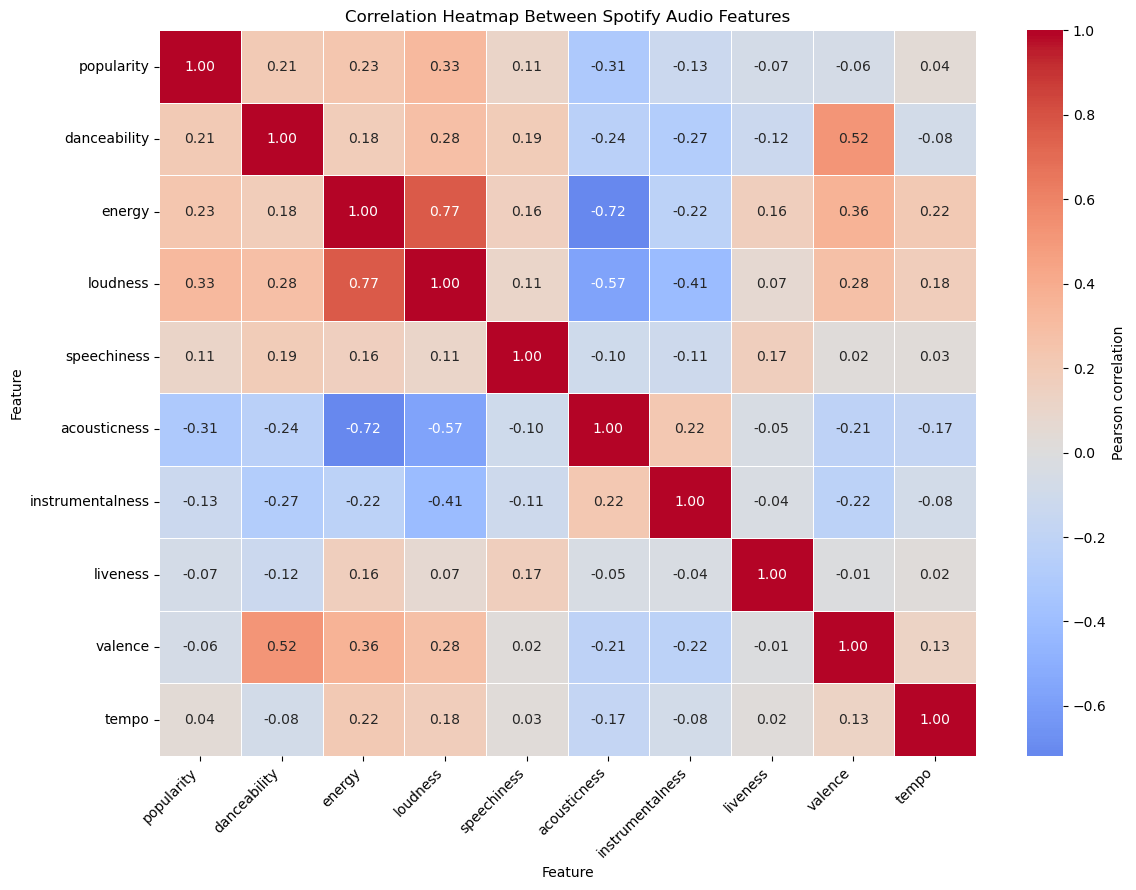

In [21]:
numeric_columns = final_df.select_dtypes(include=["number"]).columns

corr_df = final_df[numeric_columns].copy()


# -------------------------
# 2. Optional: remove identifier/time/outcome columns
# -------------------------
# Use this version if you want only Spotify/audio-related numeric features.
# If you want absolutely all numeric columns, skip this block.

excluded_columns = [
    "year",
    "decade",
    "weeks_on_board",
    "peak_rank",
    "charted_binary",
    "CSS",
    "CSS_normalized"
]

feature_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

corr_df = final_df[feature_columns].copy()


# -------------------------
# 3. Calculate correlation matrix
# -------------------------

feature_corr_matrix = corr_df.corr(method="pearson")


# -------------------------
# 4. Plot heatmap
# -------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    feature_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Correlation Heatmap Between Spotify Audio Features")
plt.xlabel("Feature")
plt.ylabel("Feature")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Appendix D. Numerical representation of feature trends across decades


In [22]:




excluded_columns = [
    "year",
    "decade",
    "weeks_on_board",
    "peak_rank",
    "charted_binary",
    "CSS",
    "CSS_normalized"
]

numeric_columns = final_df.select_dtypes(include=["number"]).columns

feature_columns = [
    col for col in numeric_columns
    if col not in excluded_columns
]

standardized_df = final_df.copy()

for col in feature_columns:
    standardized_df[col + "_z"] = (
        standardized_df[col] - standardized_df[col].mean()
    ) / standardized_df[col].std()

z_columns = [col + "_z" for col in feature_columns]

decade_feature_means_z = (
    standardized_df
    .groupby("decade_label", observed=True)[z_columns]
    .mean()
    .sort_index()
    .round(3)
)

decade_feature_means_z.columns = feature_columns

decade_feature_means_z

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
decade_label,,,,,,,,,,
1950-60s,-1.038,-0.322,-0.640,-0.528,-0.178,0.843,0.191,0.033,0.028,-0.147
1970s,-0.376,-0.152,-0.103,-0.249,-0.173,0.077,0.025,0.087,0.176,0.016
1980s,-0.242,-0.024,0.160,-0.192,-0.147,-0.245,0.048,0.002,0.100,0.070
1990s,0.172,0.112,0.124,0.057,0.080,-0.234,-0.024,-0.015,0.024,-0.004
2000s,0.546,0.146,0.373,0.543,0.143,-0.329,-0.126,-0.038,-0.041,0.057
2010-20s,1.207,0.324,0.260,0.528,0.327,-0.331,-0.165,-0.080,-0.294,0.045


## Appendix E. Top 3 best-performing CSS genres for each decade, minimum 50 charted tracks


In [23]:


min_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

top3_genres_by_decade_css = (
    charted_df
    .dropna(subset=["decade_label", "track_genre", "CSS_normalized"])
    .groupby(["decade_label", "track_genre"], as_index=False, observed=True)
    .agg(
        mean_CSS_normalized=("CSS_normalized", "mean"),
        number_of_tracks=("track_genre", "count")
    )
)

# Keep only genres with at least 10 charted tracks in that decade
top3_genres_by_decade_css = top3_genres_by_decade_css[
    top3_genres_by_decade_css["number_of_tracks"] >= min_tracks
]

# Sort and select Top 3 per decade
top3_genres_by_decade_css = (
    top3_genres_by_decade_css
    .sort_values(
        ["decade_label", "mean_CSS_normalized"],
        ascending=[True, False]
    )
    .groupby("decade_label", observed=True)
    .head(3)
    .reset_index(drop=True)
)

# Add rank within each decade
top3_genres_by_decade_css["rank_within_decade"] = (
    top3_genres_by_decade_css
    .groupby("decade_label", observed=True)["mean_CSS_normalized"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Round score
top3_genres_by_decade_css["mean_CSS_normalized"] = (
    top3_genres_by_decade_css["mean_CSS_normalized"].round(3)
)

# Reorder columns
top3_genres_by_decade_css = top3_genres_by_decade_css[
    [
        "decade_label",
        "rank_within_decade",
        "track_genre",
        "mean_CSS_normalized",
        "number_of_tracks"
    ]
]

top3_genres_by_decade_css

,decade_label,rank_within_decade,track_genre,mean_CSS_normalized,number_of_tracks
0,1950-60s,1,rockabilly,38.226,74
1,1950-60s,2,rock-n-roll,34.210,187
2,1950-60s,3,british,33.258,65
3,1970s,1,pop,64.137,202
4,1970s,2,disco,57.721,163
5,1970s,3,singer-songwriter,35.711,86
6,1980s,1,disco,88.974,105
7,1980s,2,pop,78.924,245
8,1980s,3,synth-pop,50.529,170
9,1990s,1,pop,115.926,180


## Appendix F. Standardized genre feature profiles


In [9]:
selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_tracks = 50

genre_counts = final_df["track_genre"].value_counts()

valid_genres = genre_counts[
    genre_counts >= min_tracks
].index

genre_feature_df = final_df[
    final_df["track_genre"].isin(valid_genres)
].copy()

genre_feature_means = (
    genre_feature_df
    .groupby("track_genre")[selected_features]
    .mean()
)


genre_feature_means_z = genre_feature_means.apply(
    lambda col: (col - col.mean()) / col.std(),
    axis=0
).round(2)

genre_feature_means_z.style \
    .background_gradient(cmap="Blues", subset=["danceability"]) \
    .background_gradient(cmap="Greens", subset=["energy"]) \
    .background_gradient(cmap="Purples", subset=["loudness"]) \
    .background_gradient(cmap="Oranges", subset=["speechiness"]) \
    .background_gradient(cmap="Reds", subset=["acousticness"]) \
    .background_gradient(cmap="Greys", subset=["instrumentalness"]) \
    .background_gradient(cmap="YlGn", subset=["liveness"]) \
    .background_gradient(cmap="PuRd", subset=["valence"]) \
    .background_gradient(cmap="YlOrBr", subset=["tempo"]) \
    .background_gradient(cmap="BuGn", subset=["popularity"]) \
    .format("{:.2f}")


,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,,,
acoustic,1.37,0.36,0.05,0.87,-0.48,-0.36,-0.84,-0.47,-0.22,0.50
afrobeat,-1.31,1.15,0.95,0.55,0.12,-0.47,0.61,0.25,1.64,-1.08
alt-rock,1.44,-0.08,0.95,1.10,-0.39,-1.08,-0.58,-0.60,-0.37,1.12
alternative,0.17,-0.21,0.62,0.38,-0.21,-0.93,0.07,-0.21,-0.06,0.71
ambient,-0.09,-1.90,-1.75,-2.36,-0.54,1.11,3.06,-1.05,-2.27,-1.54
bluegrass,-0.97,0.09,-0.62,-0.48,-0.44,0.83,0.03,0.26,1.23,0.99
blues,-0.80,0.16,-0.17,-0.22,-0.33,0.11,-0.24,0.74,0.82,0.29
brazil,-0.42,-0.06,-1.06,-1.00,-0.38,1.14,-0.14,-0.38,0.53,-0.36
british,0.41,0.05,0.34,0.44,-0.39,-0.37,-0.35,-0.28,0.28,0.07


## Appendix G. Genre success by decade based on mean CSS_normalized


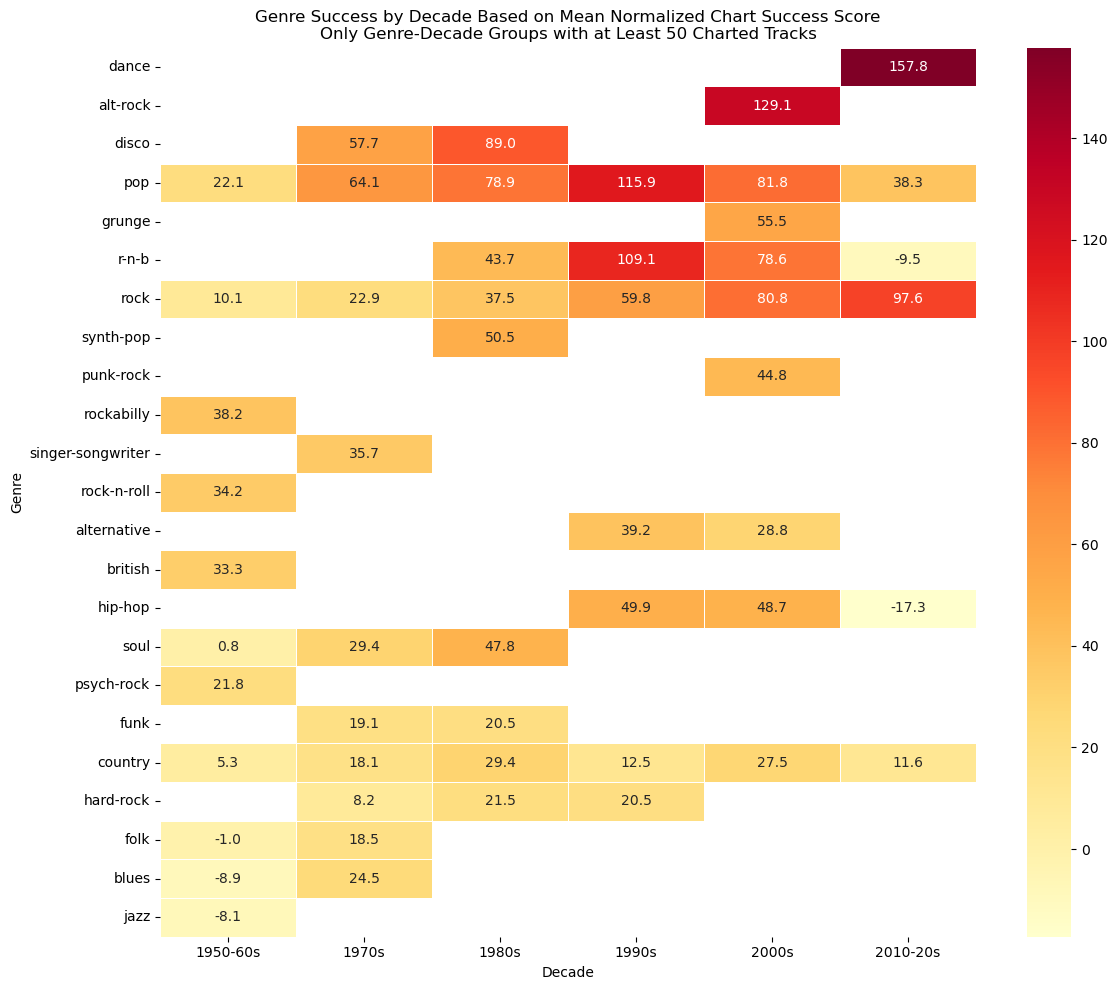

In [24]:
min_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

decade_order = [
    "1950-60s",
    "1970s",
    "1980s",
    "1990s",
    "2000s",
    "2010-20s"
]

charted_df["decade_label"] = pd.Categorical(
    charted_df["decade_label"],
    categories=decade_order,
    ordered=True
)


genre_decade_css = (
    charted_df
    .dropna(subset=["decade_label", "track_genre", "CSS_normalized"])
    .groupby(["track_genre", "decade_label"], as_index=False, observed=True)
    .agg(
        mean_CSS_normalized=("CSS_normalized", "mean"),
        number_of_tracks=("track_genre", "count")
    )
)

genre_decade_css.head()

genre_decade_css_filtered = genre_decade_css[
    genre_decade_css["number_of_tracks"] >= min_tracks
].copy()

genre_decade_css_filtered["mean_CSS_normalized"] = (
    genre_decade_css_filtered["mean_CSS_normalized"].round(3)
)

genre_decade_css_filtered.sort_values(
    ["decade_label", "mean_CSS_normalized"],
    ascending=[True, False]
)

genre_decade_heatmap = genre_decade_css_filtered.pivot(
    index="track_genre",
    columns="decade_label",
    values="mean_CSS_normalized"
)

# Sort genres by their overall average CSS_normalized across decades
genre_decade_heatmap = genre_decade_heatmap.loc[
    genre_decade_heatmap.mean(axis=1).sort_values(ascending=False).index
]

genre_decade_heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(
    genre_decade_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Genre Success by Decade Based on Mean Normalized Chart Success Score\n"
    "Only Genre-Decade Groups with at Least 50 Charted Tracks"
)
plt.xlabel("Decade")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

## Appendix H. Feature-specific chart-status heatmaps by genre and decade, minimum 50 charted and 50 non-charted tracks


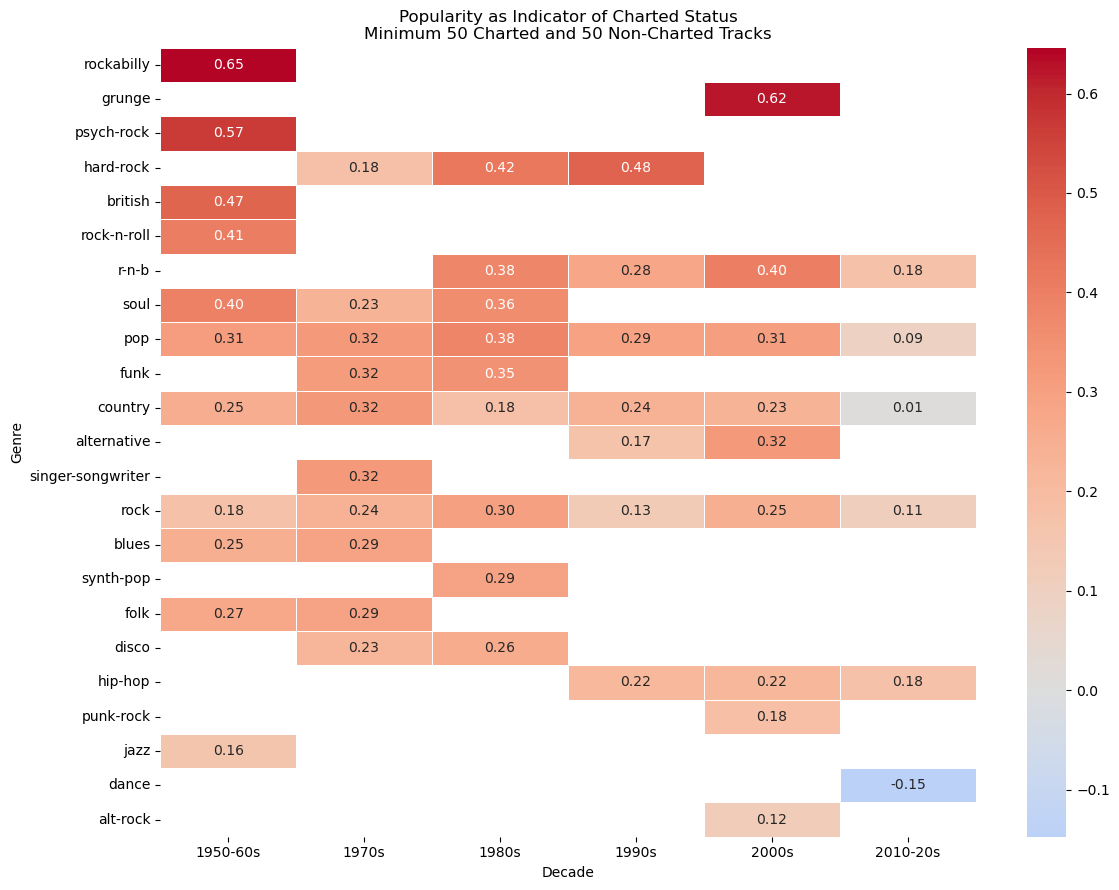

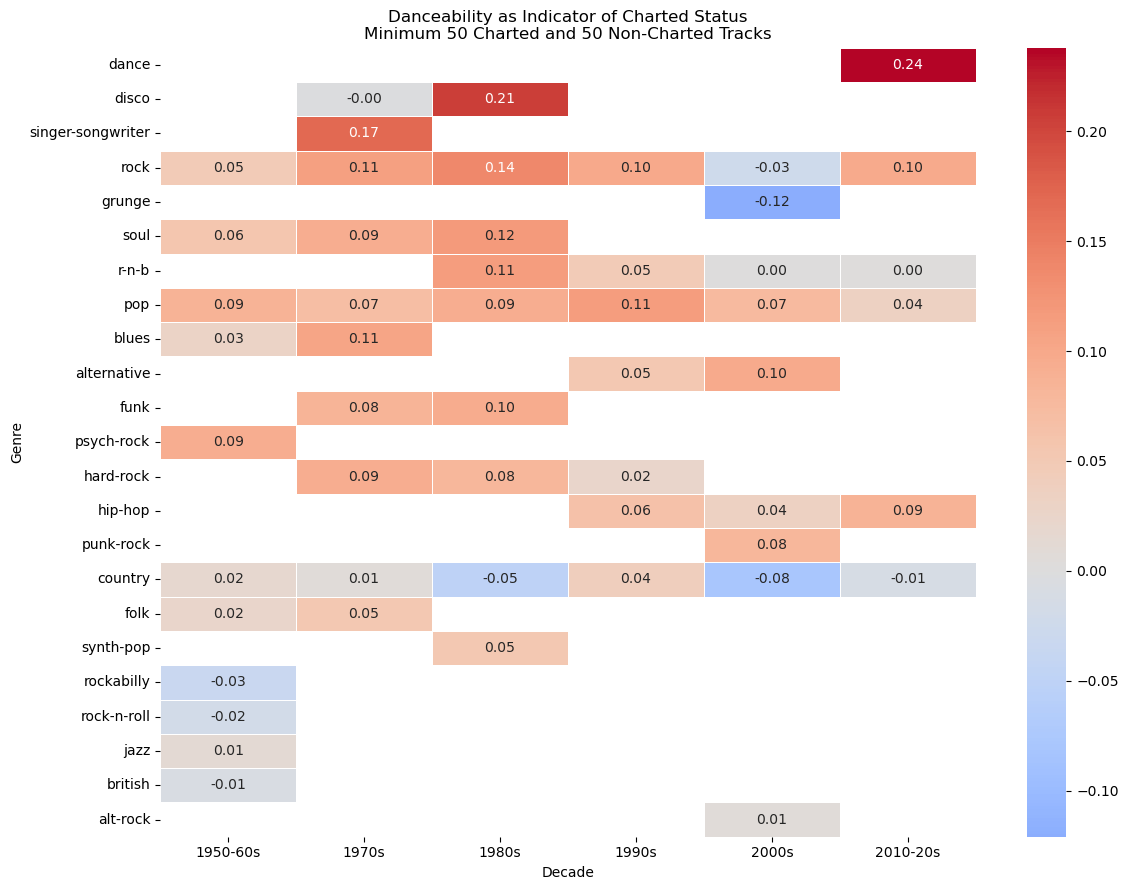

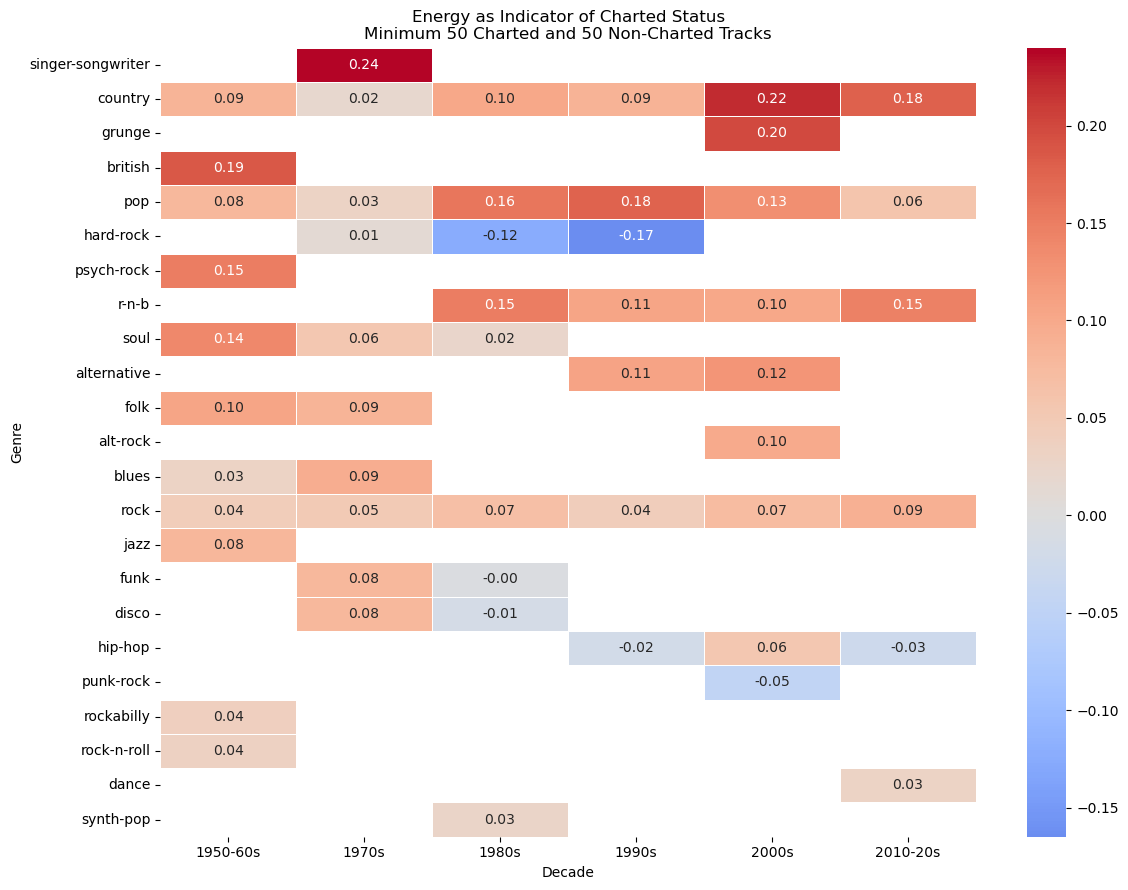

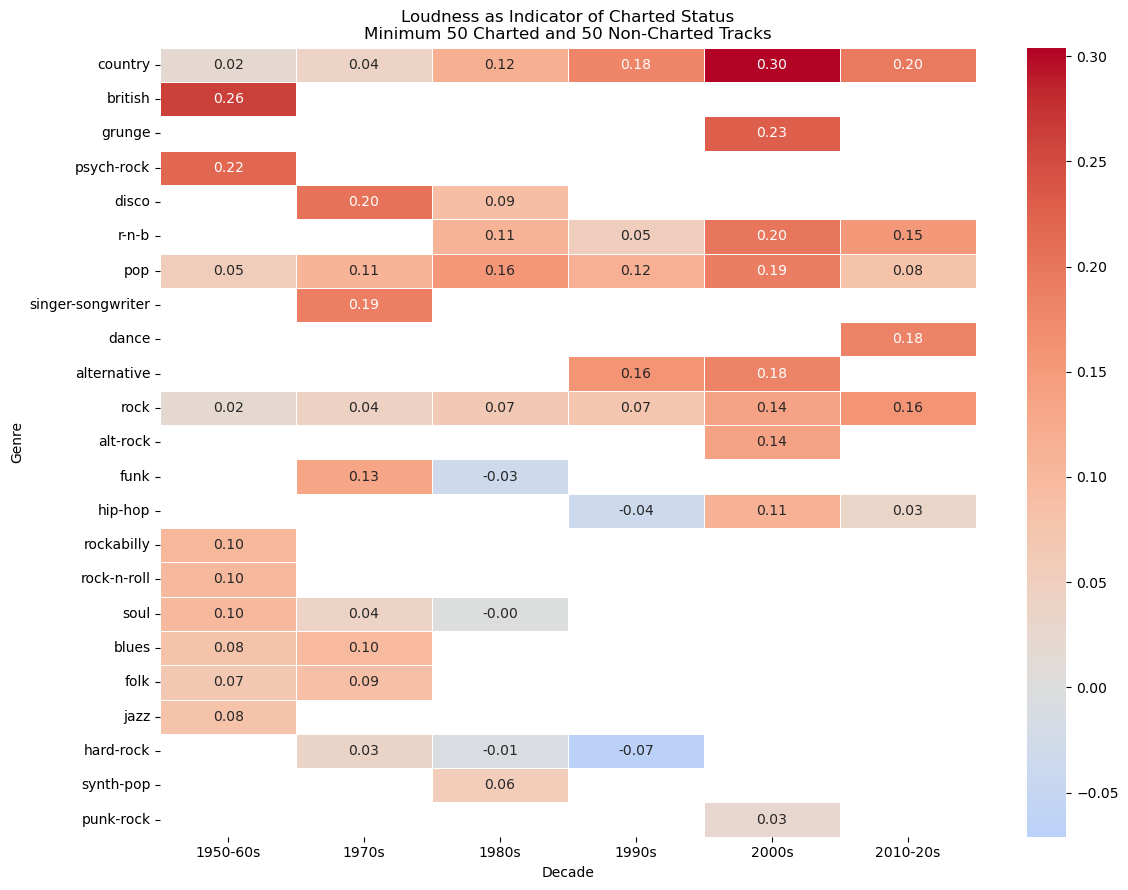

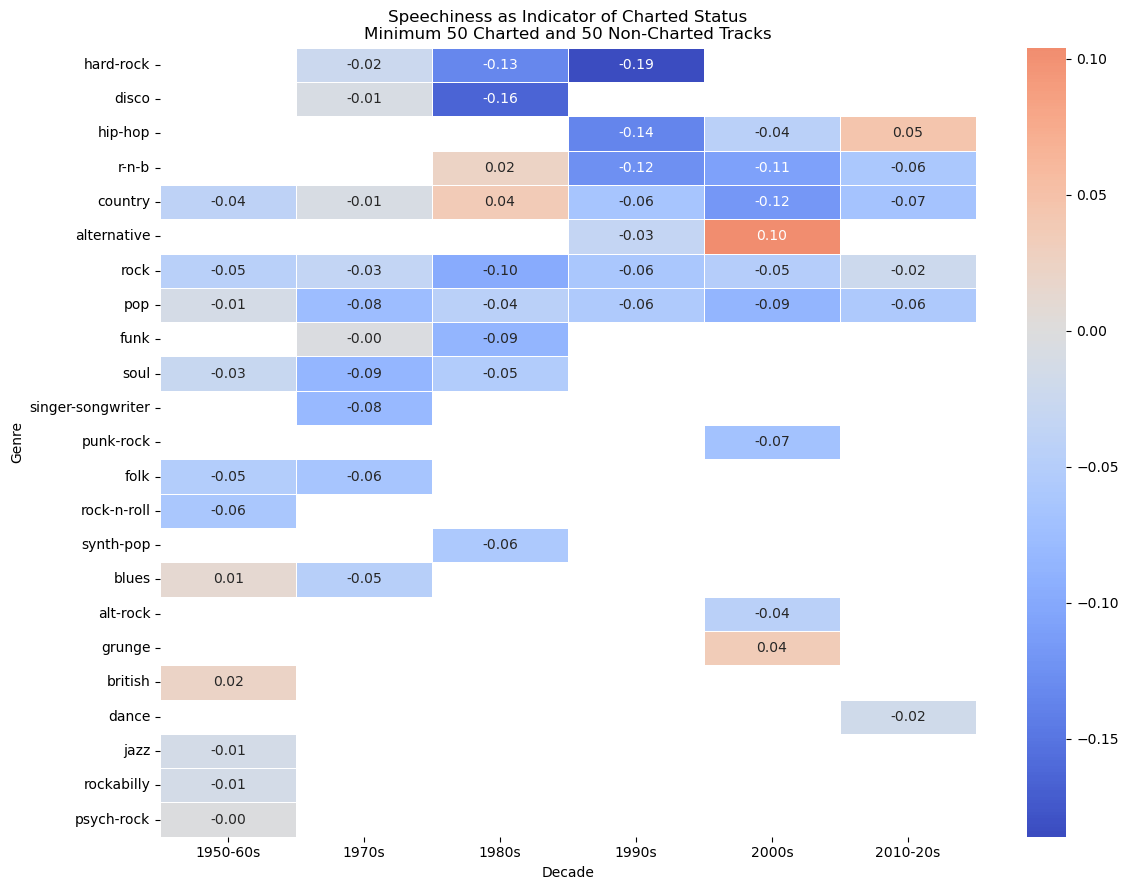

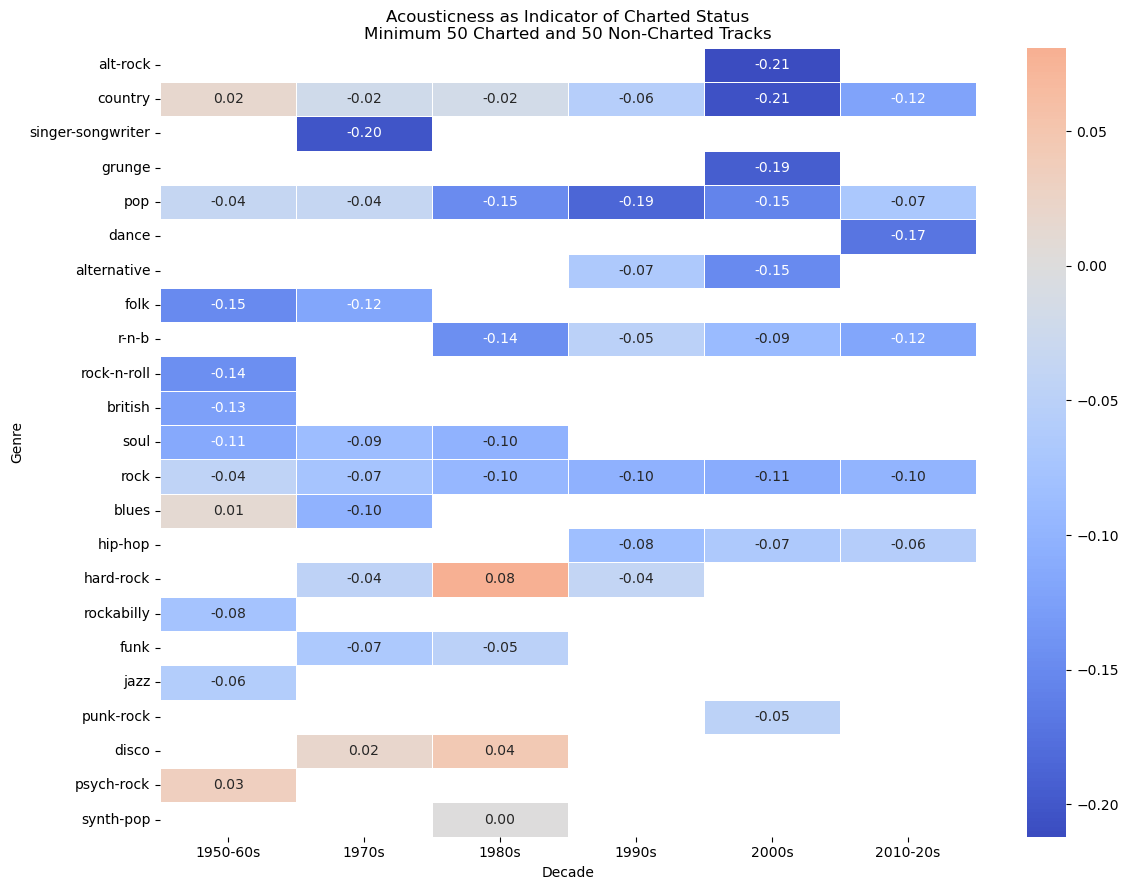

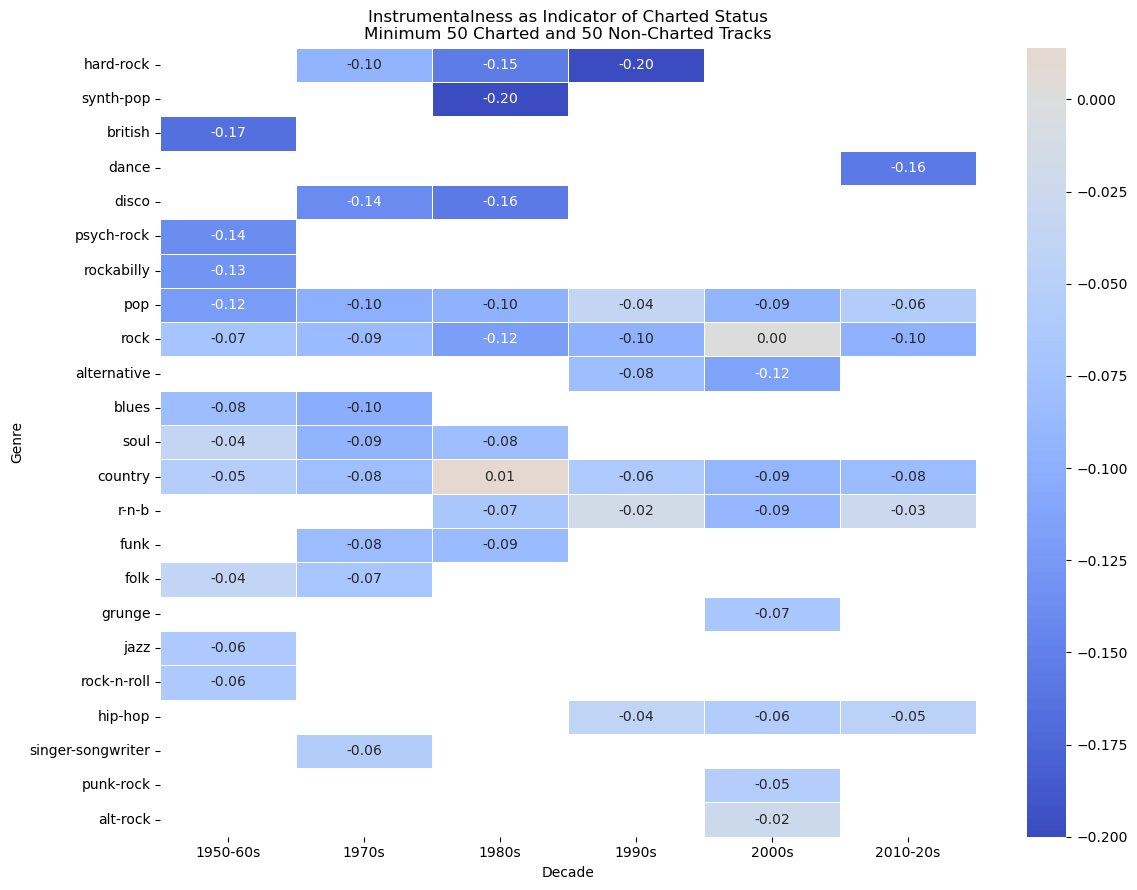

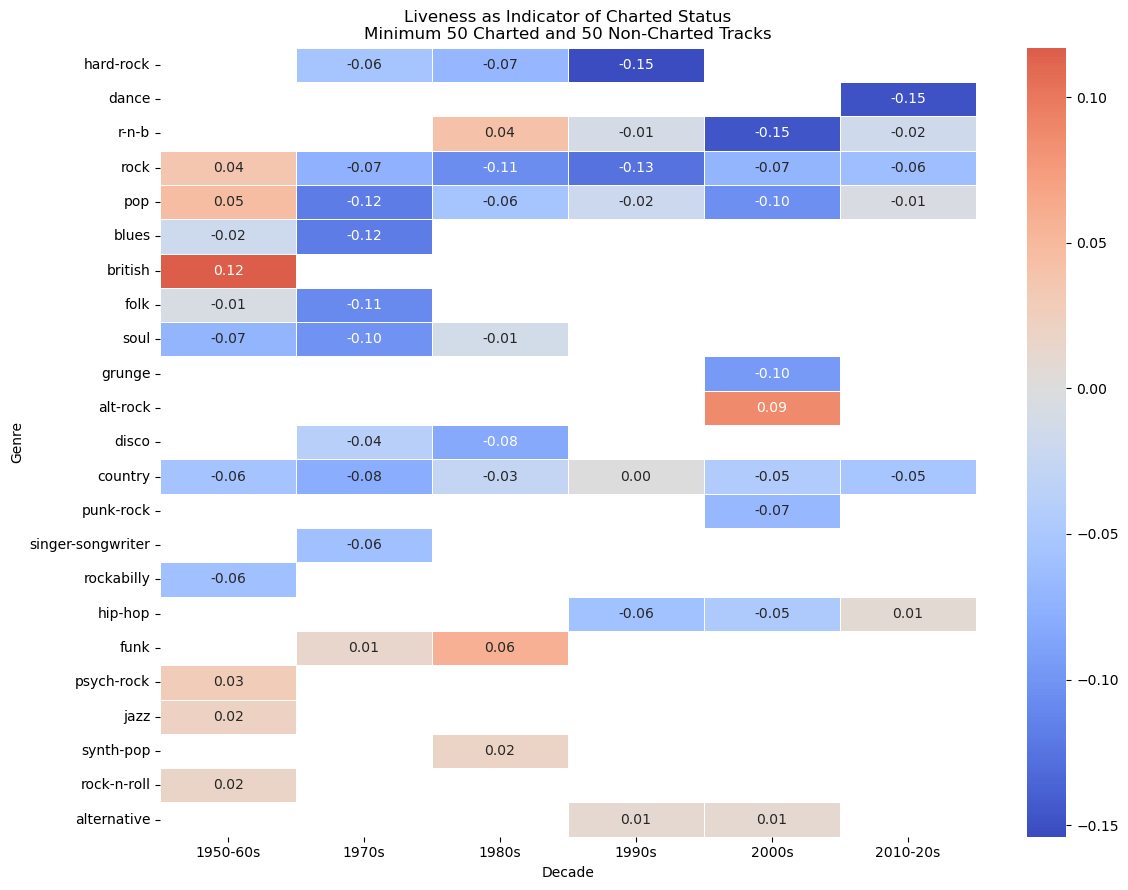

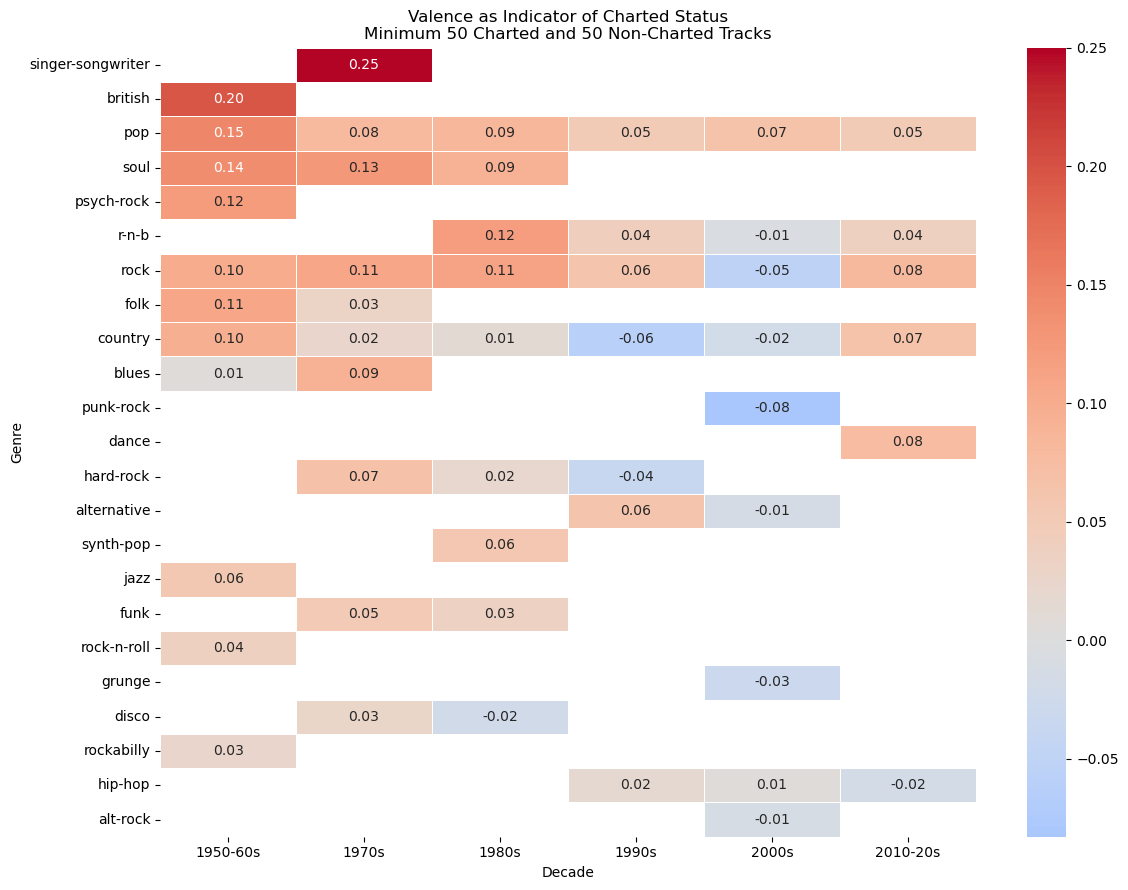

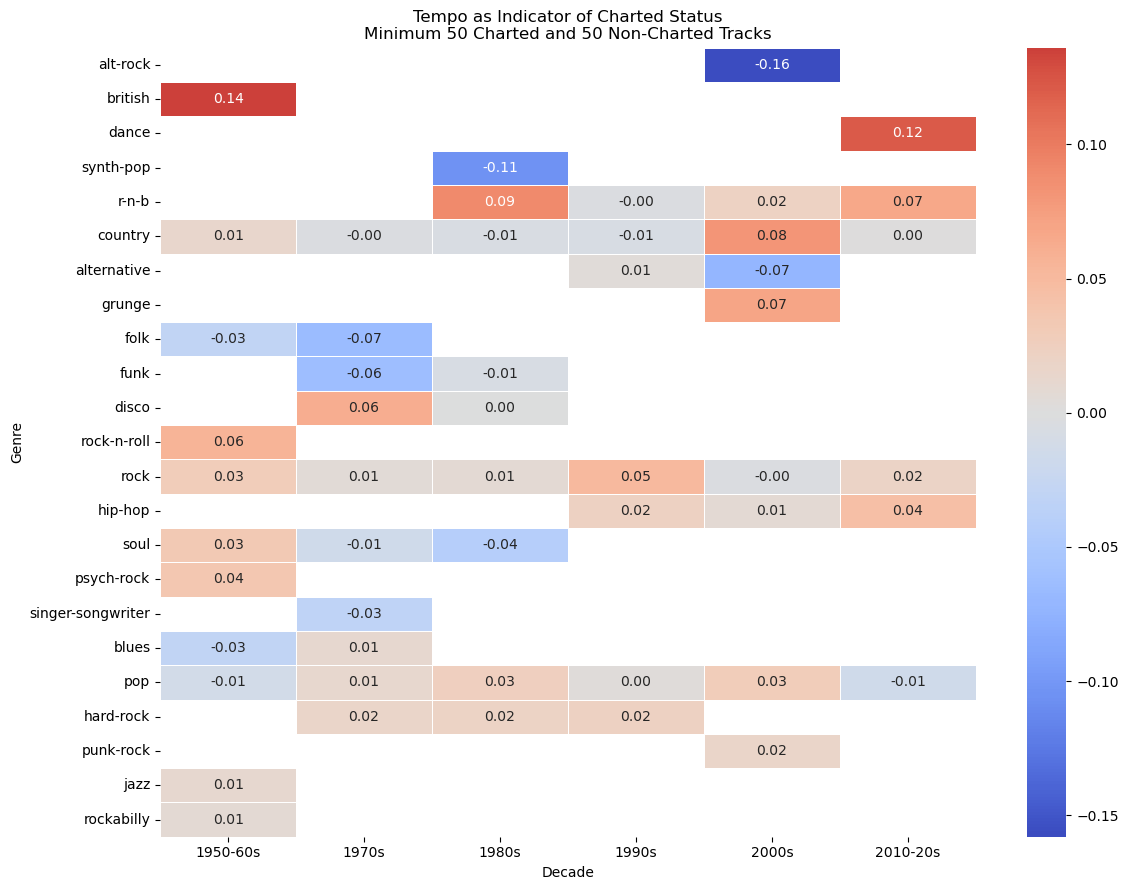

In [5]:

min_charted_count = 50
min_non_charted_count = 50

from scipy.stats import pointbiserialr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]


feature_chart_corr_results = []

for decade in final_df["decade_label"].dropna().unique():
    
    decade_data = final_df[
        final_df["decade_label"] == decade
    ].copy()
    
    for genre in decade_data["track_genre"].dropna().unique():
        
        genre_decade_data = decade_data[
            decade_data["track_genre"] == genre
        ].copy()
        
        class_counts = genre_decade_data["charted_binary"].value_counts()
        
        charted_count = class_counts.get(1, 0)
        non_charted_count = class_counts.get(0, 0)
        
        # Require at least 20 charted and 30 non-charted tracks
        if charted_count < min_charted_count:
            continue
        
        if non_charted_count < min_non_charted_count:
            continue
        
        for feature in selected_features:
            
            temp_df = genre_decade_data[
                [feature, "charted_binary"]
            ].dropna()
            
            class_counts_temp = temp_df["charted_binary"].value_counts()
            
            charted_count_temp = class_counts_temp.get(1, 0)
            non_charted_count_temp = class_counts_temp.get(0, 0)
            
            
            if charted_count_temp < min_charted_count:
                continue
            
            if non_charted_count_temp < min_non_charted_count:
                continue
            
            corr, p_value = pointbiserialr(
                temp_df["charted_binary"],
                temp_df[feature]
            )
            
            feature_chart_corr_results.append({
                "decade_label": decade,
                "track_genre": genre,
                "feature": feature,
                "correlation": corr,
                "p_value": p_value,
                "sample_size": len(temp_df),
                "charted_count": charted_count_temp,
                "non_charted_count": non_charted_count_temp
            })

feature_chart_corr_df = pd.DataFrame(feature_chart_corr_results)

feature_chart_corr_df["correlation"] = (
    feature_chart_corr_df["correlation"].round(3)
)

feature_chart_corr_df["p_value"] = (
    feature_chart_corr_df["p_value"].round(5)
)

feature_chart_corr_df.head()

for selected_feature in selected_features:
    
    feature_corr = feature_chart_corr_df[
        feature_chart_corr_df["feature"] == selected_feature
    ].copy()
    
    corr_pivot = feature_corr.pivot_table(
        index="track_genre",
        columns="decade_label",
        values="correlation"
    )
    
    if corr_pivot.empty:
        continue
    
    corr_pivot = corr_pivot.loc[
        corr_pivot.abs().max(axis=1).sort_values(ascending=False).index
    ]
    
    plt.figure(figsize=(12, 9))
    
    sns.heatmap(
        corr_pivot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    
    plt.title(
        f"{selected_feature.capitalize()} as Indicator of Charted Status\n"
        f"Minimum {min_charted_count} Charted and {min_non_charted_count} Non-Charted Tracks"
    )
    plt.xlabel("Decade")
    plt.ylabel("Genre")
    
    plt.tight_layout()
    plt.show()

## Appendix I. Feature-specific CSS_normalized heatmaps by genre and decade, minimum 50 charted tracks


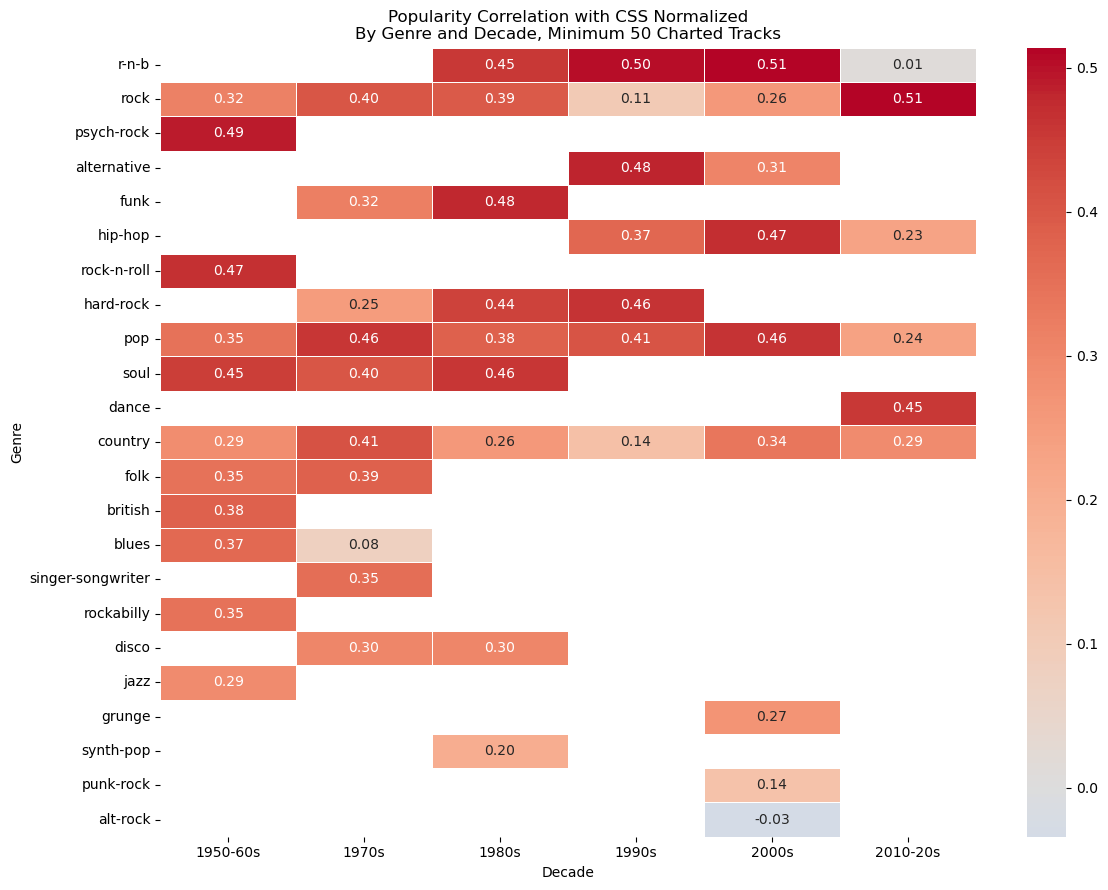

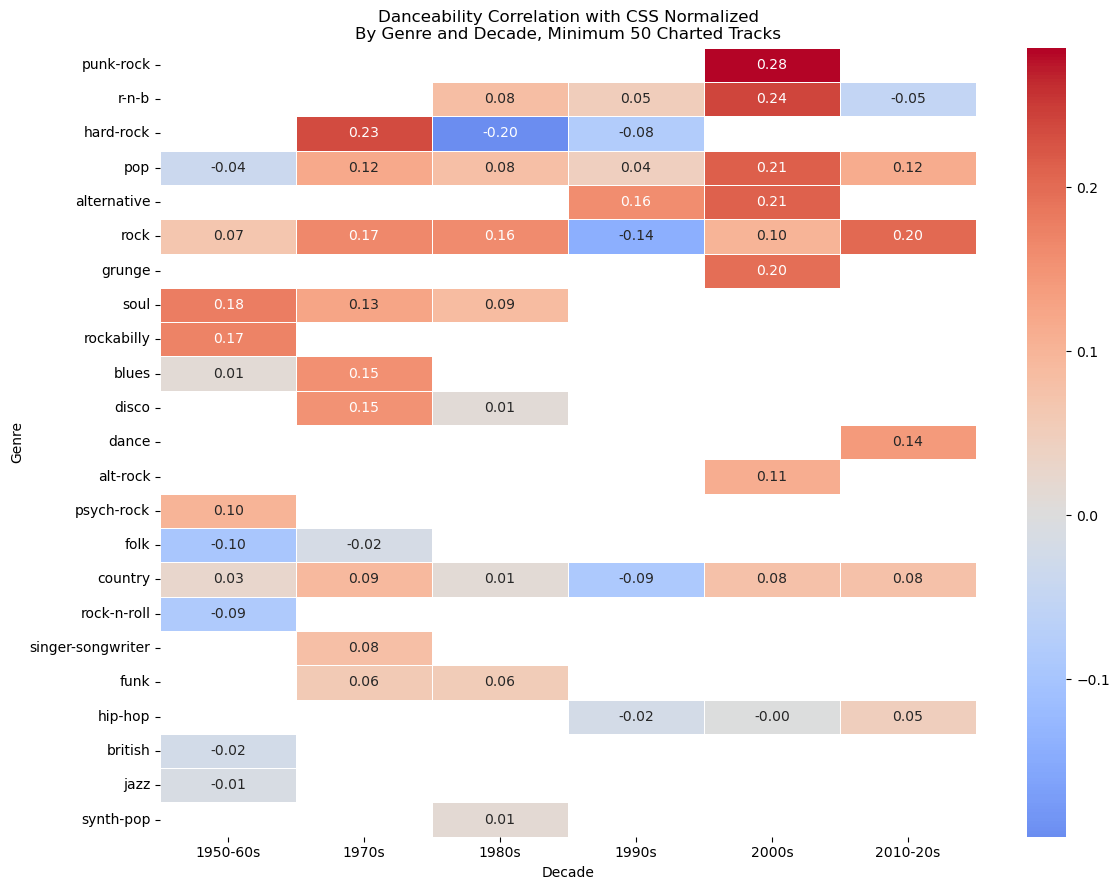

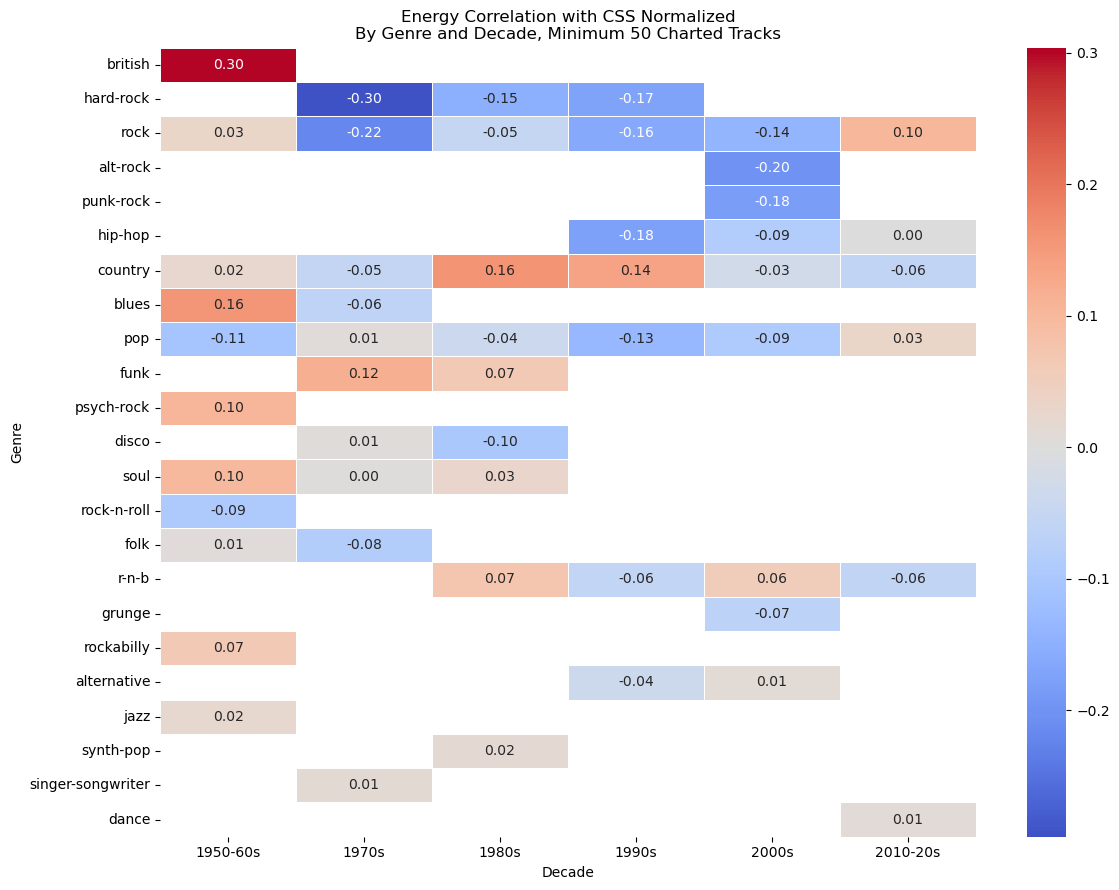

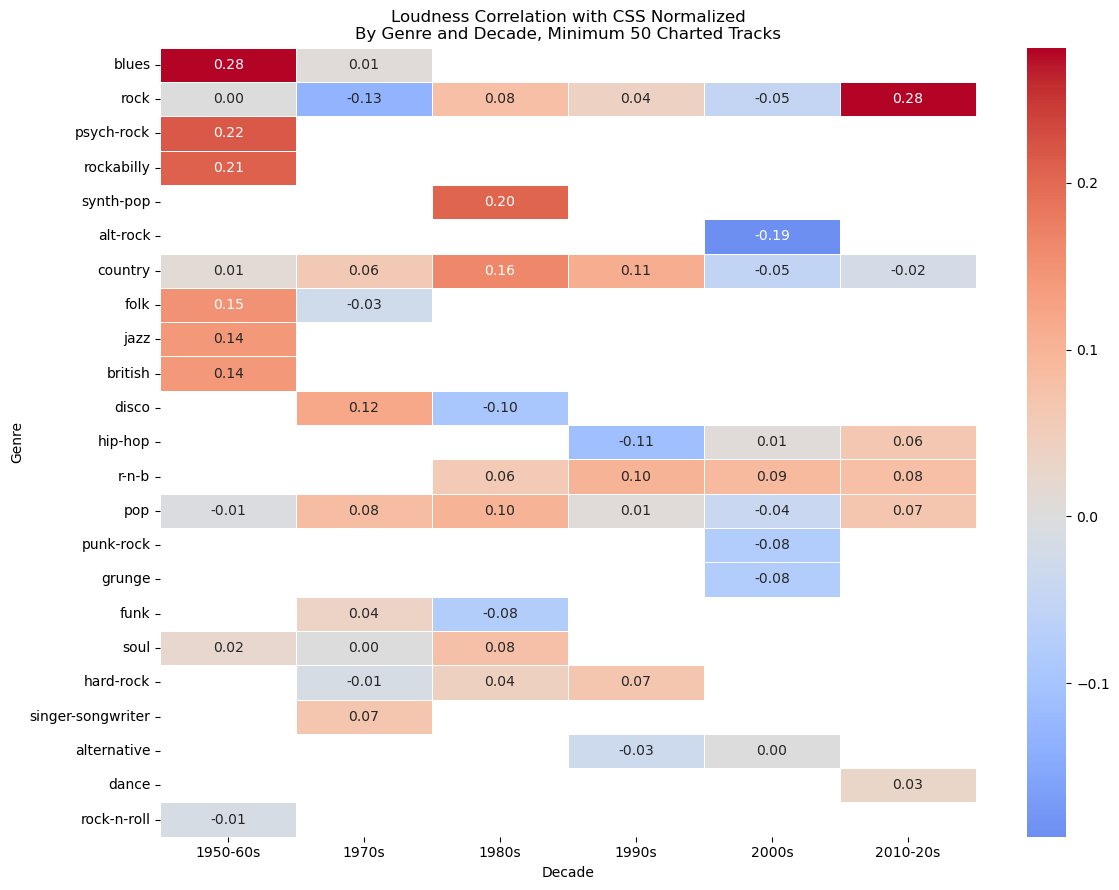

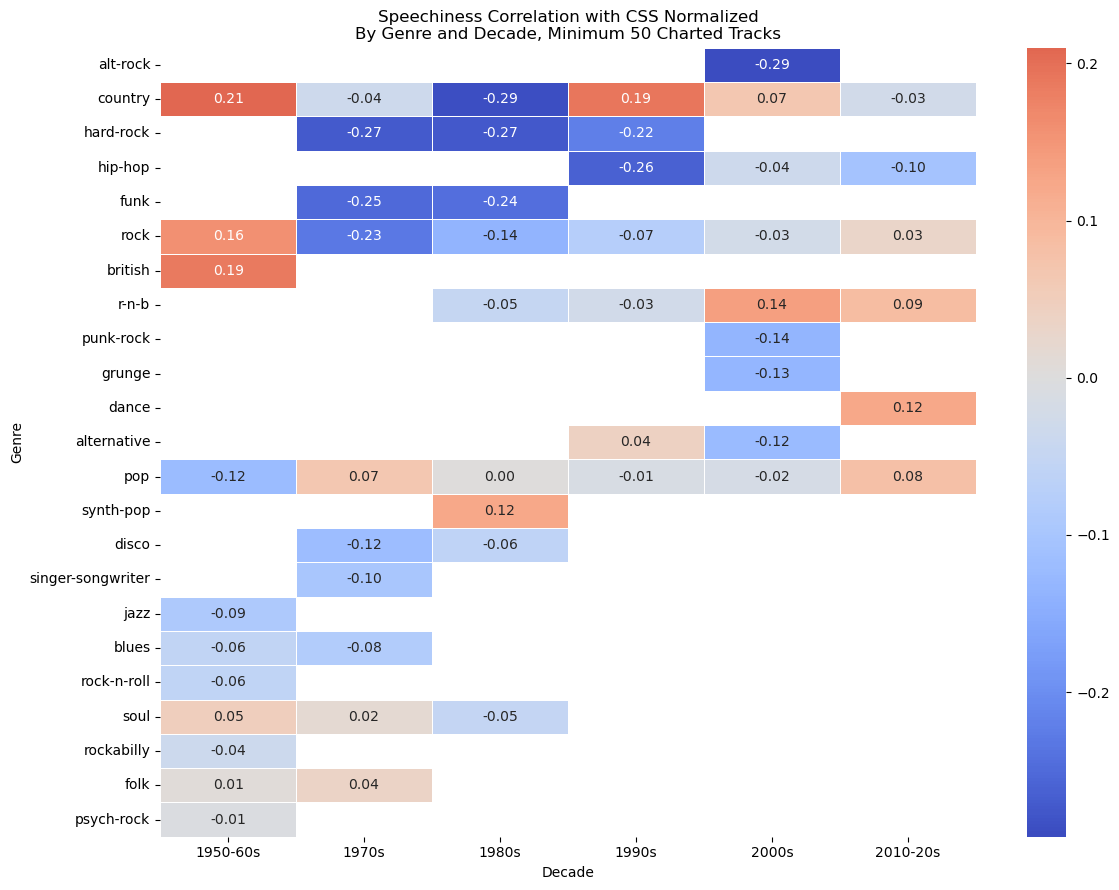

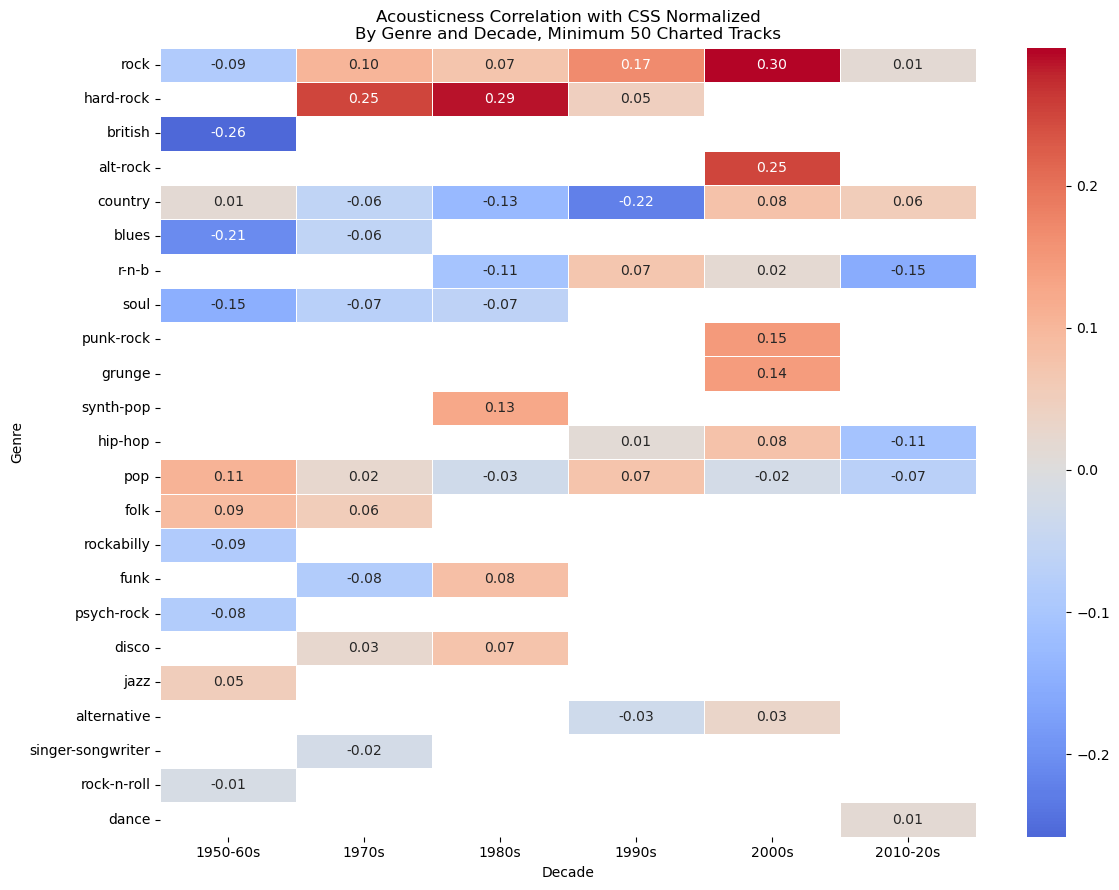

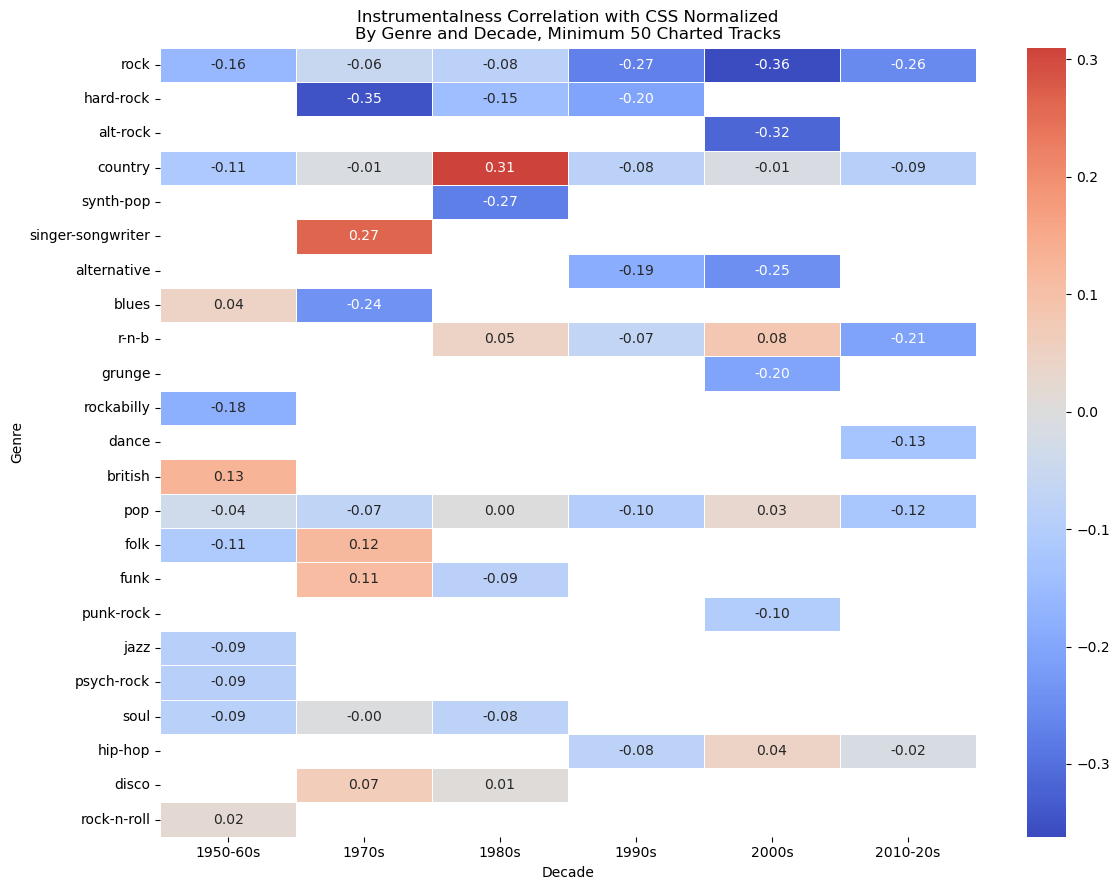

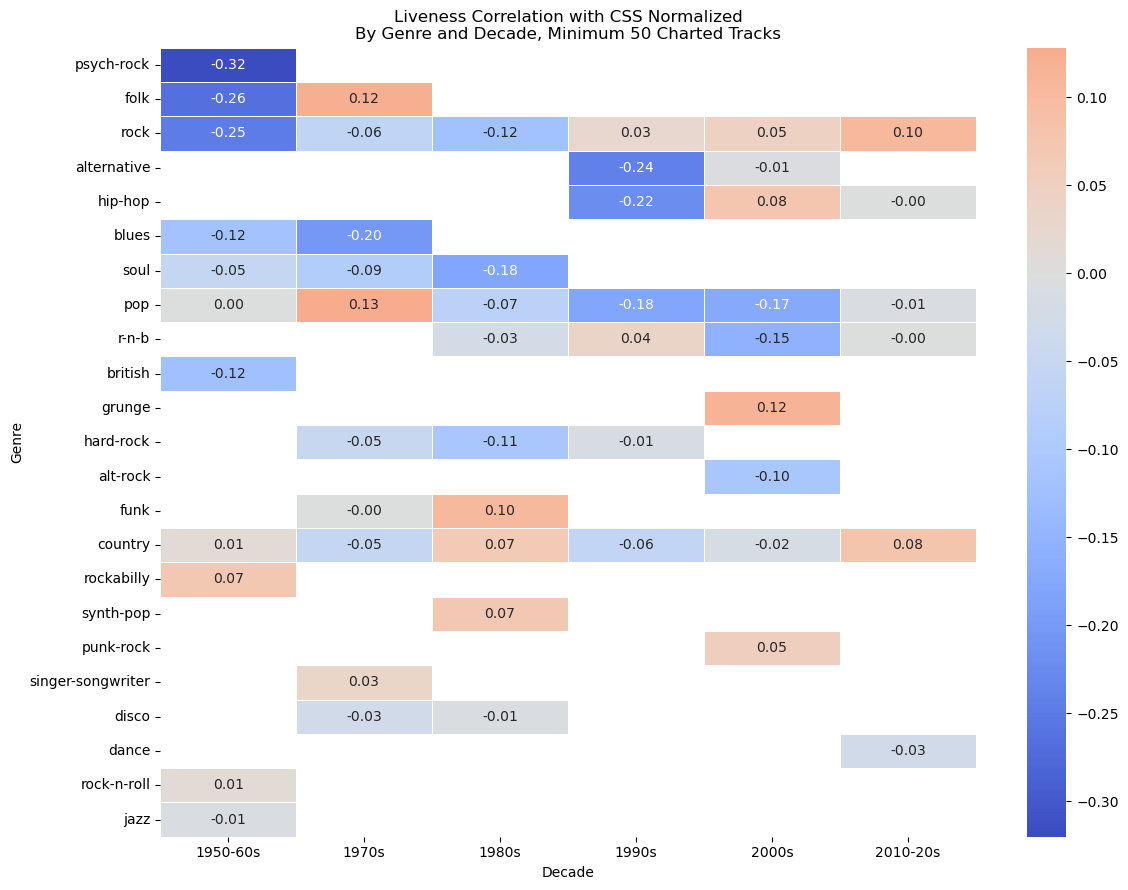

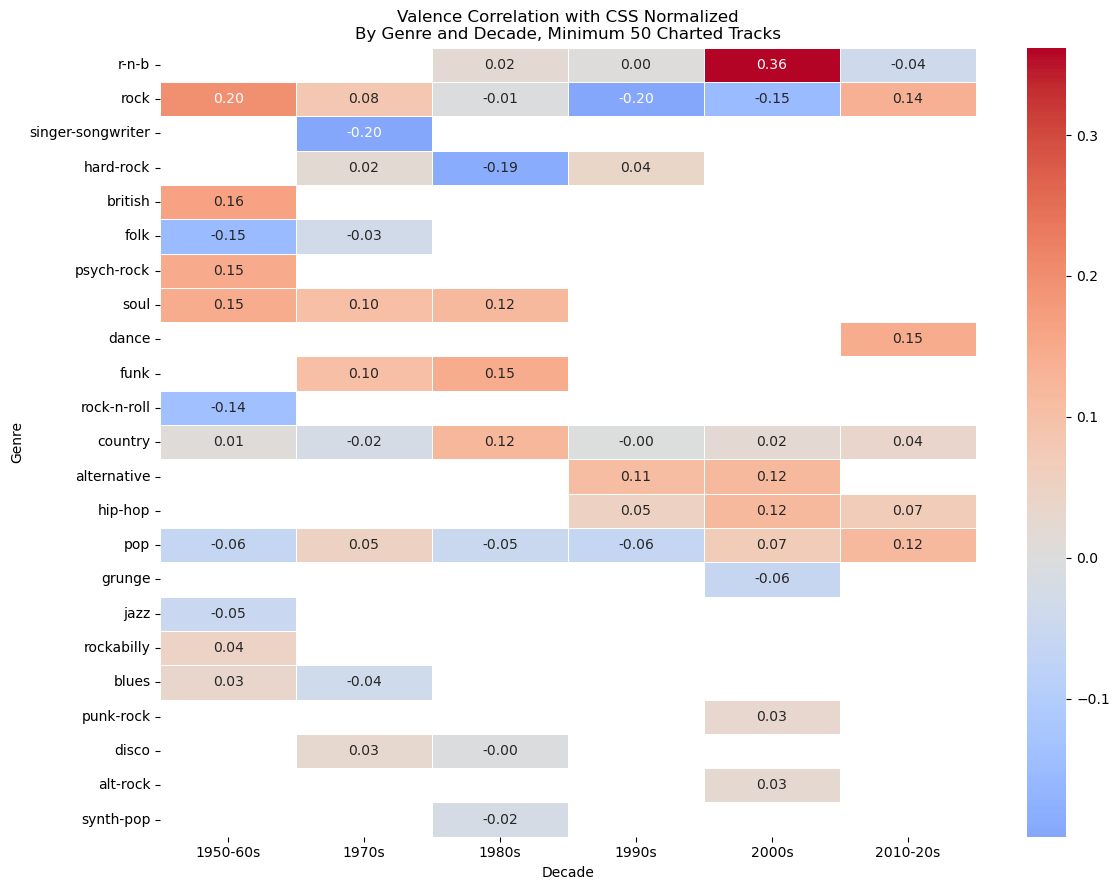

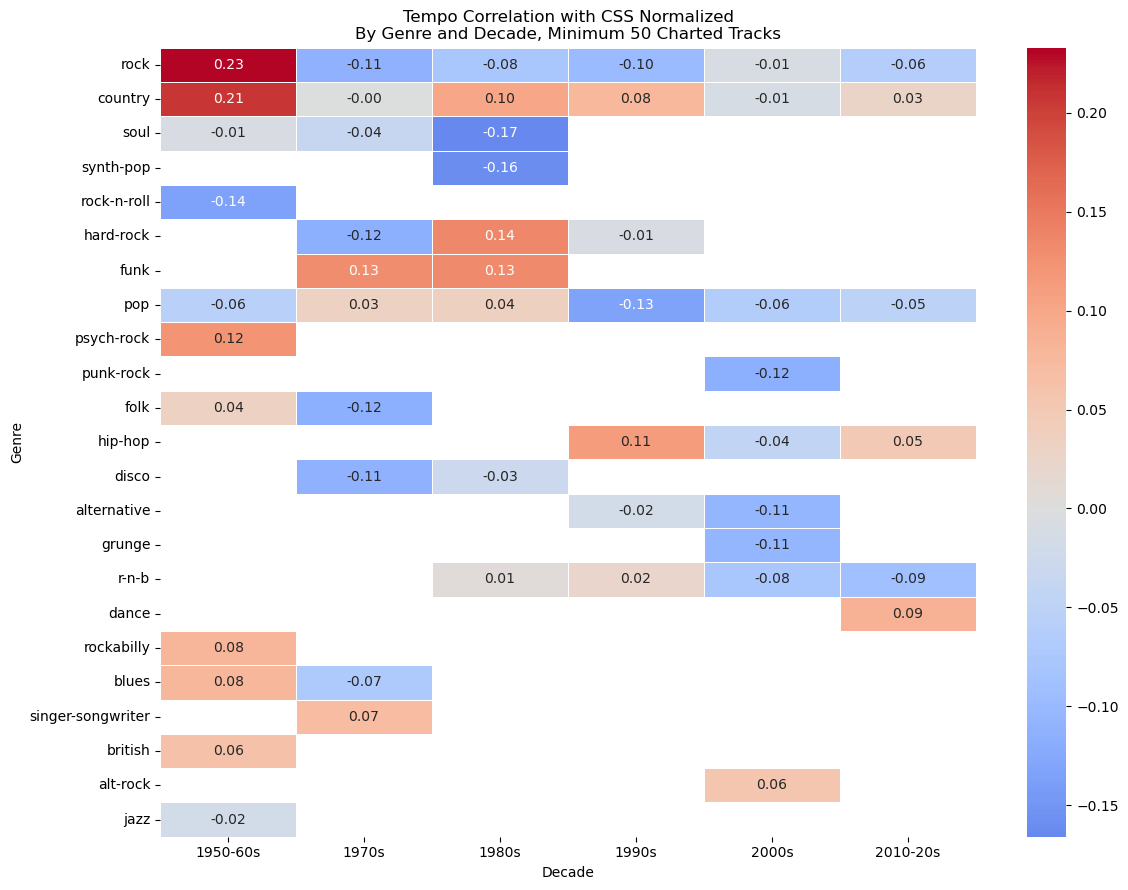

In [263]:


selected_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

min_charted_tracks = 50

charted_df = final_df[
    final_df["charted_label"] == "Charted"
].copy()

charted_df = charted_df.dropna(
    subset=["decade_label", "track_genre", "CSS_normalized"]
)

charted_df.shape

feature_css_corr_results = []

for decade in charted_df["decade_label"].dropna().unique():
    
    decade_data = charted_df[
        charted_df["decade_label"] == decade
    ].copy()
    
    for genre in decade_data["track_genre"].dropna().unique():
        
        genre_decade_data = decade_data[
            decade_data["track_genre"] == genre
        ].copy()
        
        # Require at least 50 charted tracks in this genre-decade group
        if len(genre_decade_data) < min_charted_tracks:
            continue
        
        for feature in selected_features:
            
            temp_df = genre_decade_data[
                [feature, "CSS_normalized"]
            ].dropna()
            
            # Re-check after dropping missing values
            if len(temp_df) < min_charted_tracks:
                continue
            
            # Spearman needs variation in both columns
            if temp_df[feature].nunique() < 2:
                continue
            
            if temp_df["CSS_normalized"].nunique() < 2:
                continue
            
            corr, p_value = spearmanr(
                temp_df[feature],
                temp_df["CSS_normalized"]
            )
            
            feature_css_corr_results.append({
                "decade_label": decade,
                "track_genre": genre,
                "feature": feature,
                "correlation": corr,
                "p_value": p_value,
                "sample_size": len(temp_df)
            })

feature_css_corr_df = pd.DataFrame(feature_css_corr_results)

feature_css_corr_df["correlation"] = (
    feature_css_corr_df["correlation"].round(3)
)

feature_css_corr_df["p_value"] = (
    feature_css_corr_df["p_value"].round(5)
)

for selected_feature in selected_features:
    
    feature_corr = feature_css_corr_df[
        feature_css_corr_df["feature"] == selected_feature
    ].copy()
    
    corr_pivot = feature_corr.pivot_table(
        index="track_genre",
        columns="decade_label",
        values="correlation"
    )
    
    if corr_pivot.empty:
        continue
    
    # Sort genres by strongest absolute correlation
    corr_pivot = corr_pivot.loc[
        corr_pivot.abs().max(axis=1).sort_values(ascending=False).index
    ]
    
    plt.figure(figsize=(12, 9))
    
    sns.heatmap(
        corr_pivot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    
    plt.title(
        f"{selected_feature.capitalize()} Correlation with CSS Normalized\n"
        f"By Genre and Decade, Minimum {min_charted_tracks} Charted Tracks"
    )
    plt.xlabel("Decade")
    plt.ylabel("Genre")
    
    plt.tight_layout()
    plt.show()